# 2D CUDA Threads & Blocks Lab
## Channel Estimation via CNN — 6G Physical Layer

**Platform:** Google Colab with T4 GPU &nbsp;→&nbsp; *Runtime → Change runtime type → T4 GPU*

---

## Part 0 — Problem Statement: What Are We Solving?

---

### 1. The Channel Estimation Problem

In a 5G / 6G wireless system, data is transmitted over a radio channel.  
The channel **distorts every transmitted symbol** — it introduces:
- **Amplitude scaling** (fading — signal strength varies across frequency and time)
- **Phase rotation** (the signal arrives shifted in angle)
- **Both effects vary** across subcarriers (frequency) and across OFDM symbols (time)

This distortion is captured by a complex number `H[k, l]` at every resource element:

```
Received signal:   Y[k, l]  =  H[k, l]  ×  X[k, l]  +  noise
                      ↑              ↑           ↑
                 what we         unknown      what we
                 receive         channel      transmitted
```

**Goal of channel estimation:** recover `H[k, l]` at every `(k, l)` cell so the receiver can undo the distortion and decode `X[k, l]`.

---

### 2. The OFDM Resource Grid — The 2D Canvas

OFDM (used in 5G NR, LTE, Wi-Fi) organises the transmitted signal on a 2D grid:

```
          ◄──────── OFDM symbols (time axis) ──────────►
          l=0    l=1    l=2    l=3  ...  l=13
       ┌──────┬──────┬──────┬──────┬─────┬──────┐
  k=0  │  X   │  X   │  X   │  P   │ ... │  X   │  ← subcarrier 0
  k=1  │  X   │  X   │  X   │  X   │ ... │  X   │
  k=2  │  X   │  X   │  X   │  X   │ ... │  X   │
  k=3  │  X   │  X   │  X   │  X   │ ... │  X   │
  k=4  │  X   │  X   │  X   │  P   │ ... │  X   │  ← subcarrier 4
  ...  │ ...  │ ...  │ ...  │ ...  │ ... │ ...  │
  ▲
  subcarriers (frequency axis)

  X = data symbol (unknown at receiver)
  P = pilot symbol (KNOWN value, agreed between transmitter & receiver)
```

**Key numbers (5G NR):**  `N_SC = 1200` subcarriers × `N_SYM = 14` symbols per slot

---

### 3. Pilots — The "Known Anchors" for Estimation

The transmitter inserts **known symbols (pilots)** at fixed positions.  
The receiver compares what it receives at pilot positions against what it expected:

```
At pilot (k, l):   H_est[k, l]  =  Y[k, l]  /  X_pilot[k, l]
                                          ↑ direct estimate, but only at pilot positions
```

**The problem:** pilots are sparse — they cover only ~10–15% of the grid.  
We need `H[k, l]` everywhere, not just at pilots.

**Solution:** interpolate using a CNN — treat the resource grid like a 2D image and denoise/interpolate it.

---

### 4. CNN Architecture for Channel Estimation — Two Sides of the Problem

> **Critical distinction:** The lab has a TRANSMITTER side (simulating the channel) and a RECEIVER side (estimating it).  
> Kernel 2 is on the **transmitter/channel side** — it generates test data.  
> Kernels 3+ are on the **receiver/estimation side** — they recover H.

```
╔══════════════════════════════════════════════════════════════════════════════════╗
║  TRANSMITTER / CHANNEL SIDE  (simulation — we play the role of the physical     ║
║  channel to generate test data for the lab)                                     ║
╠══════════════════════════════════════════════════════════════════════════════════╣

  H_true[k,l] = np.random.randn(...)      ← INVENTED (synthetic ground-truth channel)
  X[k,l] = transmitted data symbols       ← known at transmitter

                    ┌──────────────────────────────────────────────────────────────┐
KERNEL 1            │  Pilot Mask Init                                             │
(this lab)          │  → write binary mask: mask[k,l] = 1 where pilot, else 0     │
                    │  → purpose: tells receiver WHERE to find known symbols       │
                    │  → each thread writes ONE cell  (write-only, fully parallel) │
                    └────────────────────┬─────────────────────────────────────────┘
                                         │
                                         ▼
                    ┌──────────────────────────────────────────────────────────────┐
KERNEL 2            │  Channel Apply   Y[k,l] = H_true[k,l] × X[k,l]             │
(this lab)          │  → SIMULATES what the physical air channel does to X        │
                    │  → H_true is the KNOWN synthetic channel we created above   │
                    │  → Y is what the receiver "receives"                        │
                    │  → embarrassingly parallel: each thread does one multiply   │
                    │                                                              │
                    │  ★ H_true is NOT being estimated here — it is being USED    │
                    │    to produce Y.  Estimation happens below (receiver side). │
                    └────────────────────┬─────────────────────────────────────────┘
                                         │  Y[k,l]  (received signal, on GPU)
╠══════════════════════════════════════════════════════════════════════════════════╣
║  RECEIVER / ESTIMATION SIDE  (the CNN — receiver does NOT know H_true)          ║
║  Goal: recover H_hat ≈ H_true  using only Y and the pilot positions             ║
╠══════════════════════════════════════════════════════════════════════════════════╣
                                         │
                                         ▼
                    ┌──────────────────────────────────────────────────────────────┐
INPUT               │  Pilot observation grid fed to CNN                           │
                    │  At pilot (k,l):   H_init[k,l] = Y[k,l] / X_pilot[k,l]     │
                    │  Elsewhere:        H_init[k,l] = 0  (unknown)               │
                    │  ┌──┬──┬──┬──┬──┬──┬──┬──┐                                  │
                    │  │ 0│ 0│ 0│H │ 0│ 0│ 0│H │  P = direct estimate from pilot │
                    │  │ 0│ 0│ 0│ 0│ 0│ 0│ 0│ 0│  0 = unknown, to be filled      │
                    │  │ 0│ 0│ 0│H │ 0│ 0│ 0│H │                                  │
                    │  └──┴──┴──┴──┴──┴──┴──┴──┘                                  │
                    └────────────────────┬─────────────────────────────────────────┘
                                         │
                                         ▼
                    ┌──────────────────────────────────────────────────────────────┐
KERNEL 3            │  Conv2D Layer 1   (3×3 filter, 64 feature maps in real CNN) │
(this lab)          │  → each thread reads 3×3 neighbourhood, writes one output   │
                    │  → interpolates/denoises sparse pilot observations           │
                    │  → begins filling in H where no pilot existed               │
                    └────────────────────┬─────────────────────────────────────────┘
                                         │  (full CNN: 10–20 more Conv2D layers)
                                         ▼
                    ┌──────────────────────────────────────────────────────────────┐
CONV2D LAYERS 2–N   │  Same kernel structure repeated N times                     │
(concept only)      │  → each layer refines the estimate: H_hat gets closer to    │
                    │    H_true with each layer                                    │
                    └────────────────────┬─────────────────────────────────────────┘
                                         │
                                         ▼
                    ┌──────────────────────────────────────────────────────────────┐
OUTPUT              │  H_hat[k,l] — estimated channel across the FULL grid        │
                    │  ┌──┬──┬──┬──┬──┬──┬──┬──┐                                  │
                    │  │H̃ │H̃ │H̃ │H̃ │H̃ │H̃ │H̃ │H̃ │  ← every cell filled          │
                    │  │H̃ │H̃ │H̃ │H̃ │H̃ │H̃ │H̃ │H̃ │    H̃ ≈ H_true               │
                    │  │H̃ │H̃ │H̃ │H̃ │H̃ │H̃ │H̃ │H̃ │                               │
                    │  └──┴──┴──┴──┴──┴──┴──┴──┘                                  │
                    └──────────────────────────────────────────────────────────────┘
                    → D2H: one transfer per slot.   → Equaliser: X_hat = Y / H_hat
╚══════════════════════════════════════════════════════════════════════════════════╝
```

**Summary of the split:**

| | Kernel 1 | Kernel 2 | Kernel 3+ |
|--|----------|----------|-----------|
| **Side** | Transmitter prep | Channel simulation | Receiver / CNN |
| **H known?** | — | Yes (we invented it) | No — must estimate it |
| **Purpose** | Mark pilot positions | Generate Y = H × X | Recover H from Y + pilots |
| **In real system** | Done at transmitter | Done by the physical air | Done by receiver GPU |

---

### 5. What This Lab Implements

This lab does **not** implement the full production CNN (that has 64 filters, batch norm, residual connections).  
Instead, it uses **one representative kernel per CNN stage** to teach the GPU programming concepts:

| Lab Kernel | CNN stage it represents | Key GPU concept taught |
|------------|------------------------|------------------------|
| **Kernel 1** — Pilot mask | Input layer setup | 2D thread indexing; write-only; boundary guard |
| **Kernel 2** — Channel apply | Normalisation / preprocessing | Embarrassingly parallel; element-wise ops |
| **Kernel 3** — Conv2D pass | Conv2D hidden layer | Outer loops → thread indices; inner loop stays |

> The **same 3-kernel structure** scales directly to a  channel estimator:  
> add more Conv2D kernels (layers 2–N) and change `N_SC = 1200`, `N_SYM = 14` — the CUDA code is unchanged.

---

### 6. The 2D Structure is the Key

The OFDM resource grid is a 2D array → it maps **directly and naturally** to a 2D CUDA thread grid.  
This is the central insight of the lab:

```
OFDM cell (k, l)  →  one CUDA thread
─────────────────────────────────────────────────────────────────
k = blockIdx.y * blockDim.y + threadIdx.y   ← subcarrier  (row / freq)
l = blockIdx.x * blockDim.x + threadIdx.x   ← OFDM symbol (col / time)
idx = k * N_SYM + l                         ← flat row-major memory index
─────────────────────────────────────────────────────────────────
```

Every kernel in this lab uses **exactly these two lines** to locate its cell.

---

### What this lab teaches — Quick Reference

| # | Kernel | 2D Thread/Block concept | Channel estimation context |
|---|--------|------------------------|----------------------------|
| 1 | Pilot mask init | `dim3` block + grid; each thread owns one 2D cell; boundary guard | Mark pilot positions in OFDM resource grid |
| 2 | Channel apply | Same 2D indexing; embarrassingly parallel — no inter-thread dependency | Y[k,l] = H[k,l] × X[k,l] per resource element |
| 3 | Conv2D pass | Outer CPU loops → 2D thread indices; inner loops unchanged in kernel | One CNN layer for channel estimation |
| — | Stanford trace | `matrixAdd` from CS149 slide 28 mapped directly onto kernels 1–3 | Shows the exact `dim3` / ceiling / guard pattern |


> **Reference ** : MathWorks 5G Toolbox example —  https://www.mathworks.com/help/5g/ug/deep-learning-data-synthesis-for-5g-channel-estimation.html *"By viewing the resource grid as a 2D image, channel estimation becomes an image denoising problem where CNNs are effective."*

---
## Designer's Question — How Many Blocks and Threads Should I Create?

> *"Given a channel estimation problem, how does a CUDA programmer decide the launch configuration?"*

---

### The 5-Step CUDA Programmer's Thinking Process

---

#### STEP 1 — Identify the Parallelism in the Problem

**Question to ask:** *"What are the independent units of work?"*

If unit A does **not** need the result of unit B → they can run **in parallel on the GPU**.

| Kernel | Independent unit | Why parallel? |
|--------|-----------------|---------------|
| Pilot mask (K1) | One cell `mask[k,l]` | Rule `k%4==0 && l==3` needs only `k` and `l` — nothing else |
| Channel apply (K2) | One multiply `Y=H*X` | Needs only its own `H[k,l]` and `X[k,l]` |
| Conv2D (K3) | One output cell | Reads neighbours but **writes only its own** output cell |

> This analysis step determines **which** parts of your code go into a GPU kernel.

---

#### STEP 2 — Determine the Number of Threads Needed

**Rule:** Total threads = total independent work units (one thread per unit of work)

```
Our lab:   32 subcarriers × 16 OFDM symbols =     512 threads needed
Real 5G:  1200 × 14                          =  16,800 threads needed
```

Each thread will be assigned one `(k, l)` resource element to process.

---

#### STEP 3 — Organise Threads into Blocks and a Grid

This is the **only real design decision** the programmer makes. The rest is arithmetic.
Thread block = unit of cooperation (shared memory, sync barriers)

Shared Memory is Fast Local Memory: Each thread block has its own dedicated address space called "shared memory". This shared memory is backed by storage that you can think of as a high-performance L1 cache.

Collocation of Threads: When threads belong to the same block, CUDA knows to put them on the same Streaming Multiprocessor (SM) core

Data Reuse and Cooperation: If neighboring threads in a block need to access the same input data, they can cooperatively load that data into shared memory once, rather than each thread repeatedly fetching it from slower global memory.

```
┌─────────────────────────────────────────────────────────────┐
│  PROGRAMMER DECIDES:  block size   (e.g. 16×16)            │
│  PROGRAMMER COMPUTES: grid size    = ceil(N / block_size)   │
│  GPU HARDWARE DECIDES: which SM executes which block        │
└─────────────────────────────────────────────────────────────┘
```

**Choosing block size —ex:**

| Block | Threads/block | Warps/block | Notes |
|-------|--------------|-------------|-------|
| 8×8   | 64           | 2           | Good for small grids |
| **16×16** | **256**  | **8**       | **★ Best default for 2D** |
| 32×32 | 1024         | 32          | Maximum allowed |

So, while you launch 1024 threads, they are grouped into warps, and these warps are then managed and scheduled by the GPU's SMs in a way that maximizes utilization, rather than all 1024 running truly "at once."

**Computing grid size — always use ceiling:**
```python
grid_x = math.ceil(N_SYM / block_x)   # blocks needed along time axis (cols)
grid_y = math.ceil(N_SC  / block_y)   # blocks needed along freq axis  (rows)
```
`ceil()` ensures **no resource element is ever missed**, even when N is not a multiple of block size.

---

#### STEP 4 — GPU Hardware Schedules Automatically (SM Assignment)

The programmer **never** specifies which physical core (SM) runs which block.  
The GPU's hardware work scheduler does this dynamically and transparently.

```
Programmer writes:   kernel<<<grid, block>>>(args)
                              ↓
GPU Work Scheduler:  assigns blocks to available SMs as they free up
                     (dynamic, load-balanced, automatic)
                              ↓
Result:  same program runs correctly on a 6-SM laptop GPU
         AND on an 80-SM data-centre GPU — ZERO code change needed
```

> **SM = Streaming Multiprocessor** — the GPU's parallel compute unit.  
> A V100 GPU has 80 SMs. Each SM runs multiple blocks simultaneously.  
> All threads in one block **always run on the same SM** (so they can share fast on-chip memory).

---

#### STEP 5 — Add Boundary Guard in Every Kernel

Because `ceil()` may launch **more threads than data elements**, idle edge threads must be stopped before they write out-of-bounds memory:

```c
if (k < N_sc && l < N_sym)      // ← ALWAYS include this guard
    output[k * N_sym + l] = ...; // only active threads write
```

Without this guard: memory corruption. With it: idle threads simply exit harmlessly.

---

### Complete Mental Model — One Diagram

```
Problem                  Programmer                GPU Hardware
─────────────────        ──────────────────────    ─────────────────────
N_SC × N_SYM             Step 1: find parallelism  SM 0 → block (0,0)
resource elements   →    Step 2: count threads  →  SM 1 → block (0,1)
(512 cells)              Step 3: choose 16×16      SM 2 → block (1,0)
                         Step 3: compute grid=2×1  ...
                         Step 4: launch <<<G,B>>>  (scheduler fills SMs
                         Step 5: add guard           as they free up)
```

---


In [ ]:
# ── Designer's Launch Config Calculator ──────────────────────────────────────
# Run this cell to see EXACTLY how a programmer sizes blocks and grids.

def design_launch(N_sc, N_sym, block_size=16, label=""):
    """
    Given problem dimensions and block size, print the complete
    launch configuration a CUDA developer would write.
    """
    bx = by = block_size
    gx = math.ceil(N_sym / bx)          # grid along OFDM symbol axis (x / cols)
    gy = math.ceil(N_sc  / by)          # grid along subcarrier axis  (y / rows)
    total   = gx * gy * bx * by         # all threads launched (incl. idle edge threads)
    active  = N_sc * N_sym              # threads that do real work
    idle    = total - active
    eff     = active / total * 100

    print(f"\n{'═'*62}")
    print(f"  {label or f'{N_sc} sc × {N_sym} sym'}")
    print(f"{'═'*62}")
    print(f"  Step 1 │ Parallelism: each (k,l) cell is independent")
    print(f"  Step 2 │ Threads needed              : {N_sc}×{N_sym} = {active:,}")
    print(f"  Step 3 │ Block chosen (programmer)   : {bx}×{by} = {bx*by} threads/block")
    print(f"  Step 3 │ Grid computed (arithmetic)  : "
          f"ceil({N_sym}/{bx})={gx} × ceil({N_sc}/{by})={gy} = {gx*gy} blocks")
    print(f"         │ Total threads launched      : {gx}×{gy}×{bx*by} = {total:,}")
    print(f"  Step 4 │ SM assignment               : handled by GPU hardware scheduler")
    print(f"  Step 5 │ Idle (boundary guard stops) : {idle:,}  ({100-eff:.1f}% waste)")
    print(f"         │ Efficiency                  : {eff:.1f}%")
    print(f"\n  ── C++ CUDA ──────────────────────────────────────────")
    print(f"     dim3 threadsPerBlock({bx}, {by});")
    print(f"     dim3 numBlocks({gx}, {gy});")
    print(f"     kernel<<<numBlocks, threadsPerBlock>>>(args);")
    print(f"\n  ── PyCUDA ────────────────────────────────────────────")
    print(f"     kernel_fn(args, block=({bx},{by},1), grid=({gx},{gy},1))")
    return gx, gy

# ══════════════════════════════ [ DESIGN ] ════════════════════════════════════
print("DESIGNER'S QUESTION: How many blocks and threads for channel estimation?")

# ── Q1: Our lab grid ──────────────────────────────────────────────────────────
design_launch(N_SC, N_SYM, block_size=16,
              label=f"Lab grid — {N_SC} subcarriers × {N_SYM} OFDM symbols")

# ── Q2: Effect of different block sizes on the same problem ───────────────────
print(f"\n\n  Comparing block sizes for the same problem ({N_SC}×{N_SYM}):")
print(f"  {'Block':>8}  {'Thds/blk':>9}  {'Grid':>12}  {'Total thds':>11}  {'Efficiency':>11}")
print(f"  {'─'*8}  {'─'*9}  {'─'*12}  {'─'*11}  {'─'*11}")
for bsz in [4, 8, 16, 32]:
    gx = math.ceil(N_SYM / bsz);  gy = math.ceil(N_SC / bsz)
    total = gx * gy * bsz * bsz;  eff = N_SC * N_SYM / total * 100
    best = "  ← best default" if bsz == 16 else ""
    print(f"  {bsz}×{bsz}  {bsz*bsz:>10}  {gy}×{gx:>2}={gx*gy:>4} blks"
          f"  {total:>8,} thds  {eff:>9.1f}%{best}")

# ── Q3: How does the answer change for REAL 5G grids? ─────────────────────────
design_launch(72,   14, block_size=16, label="Real 5G —  5 MHz  (72 sc × 14 sym / slot)")
design_launch(1200, 14, block_size=16, label="Real 5G — 100 MHz (1200 sc × 14 sym / slot)")

DESIGNER'S QUESTION: How many blocks and threads for channel estimation?

══════════════════════════════════════════════════════════════
  Lab grid — 32 subcarriers × 16 OFDM symbols
══════════════════════════════════════════════════════════════
  Step 1 │ Parallelism: each (k,l) cell is independent
  Step 2 │ Threads needed              : 32×16 = 512
  Step 3 │ Block chosen (programmer)   : 16×16 = 256 threads/block
  Step 3 │ Grid computed (arithmetic)  : ceil(16/16)=1 × ceil(32/16)=2 = 2 blocks
         │ Total threads launched      : 1×2×256 = 512
  Step 4 │ SM assignment               : handled by GPU hardware scheduler
  Step 5 │ Idle (boundary guard stops) : 0  (0.0% waste)
         │ Efficiency                  : 100.0%

  ── C++ CUDA ──────────────────────────────────────────
     dim3 threadsPerBlock(16, 16);
     dim3 numBlocks(1, 2);
     kernel<<<numBlocks, threadsPerBlock>>>(args);

  ── PyCUDA ────────────────────────────────────────────
     kernel_fn(args, block=(16,16

(1, 75)

### Deep Dive: The 2D CUDA Indexing Formula

When we launch a kernel with `grid=(GX, GY)` and `block=(BX, BY)`, the GPU creates a massive 2D array of threads. Each thread needs to know which specific OFDM cell $(k, l)$ it is responsible for.

#### 1. The Global 2D Coordinate
Imagine a large grid made of smaller tiles (Blocks):
*   **`blockIdx.y * blockDim.y`**: Moves your "starting pointer" to the beginning of the current row of blocks.
*   **`threadIdx.y`**: Moves you to the specific row inside that block.

| Axis | Formula | Meaning |
| :--- | :--- | :--- |
| **Vertical (y)** | `k = blockIdx.y * blockDim.y + threadIdx.y` | **Subcarrier index** (Row) |
| **Horizontal (x)** | `l = blockIdx.x * blockDim.x + threadIdx.x` | **OFDM Symbol index** (Column) |

#### 2. The 1D Memory Mapping (Row-Major)
Since GPU Global Memory (VRAM) is a linear 1D array, we must convert $(k, l)$ into a single integer `idx`.

$$\text{idx} = (\text{row index} \times \text{total columns}) + \text{column index}$$
$$\text{idx} = (k \times N_{SYM}) + l$$

**Visual Example:**
If $N_{SYM} = 4$ and we want the index for row $k=1$, col $l=2$:
`[ (0,0) (0,1) (0,2) (0,3) ]`  <-- Row 0 (4 elements)
`[ (1,0) (1,1) (1,2) ... ]`      <-- Row 1 starts at index 4
Index = $(1 \times 4) + 2 = 6$.

### Component Breakdown: `blockIdx.y * blockDim.y`

In CUDA, work is divided into a hierarchy. To find a thread's global position, we use this formula:

| Variable | Analogy | Definition |
| :--- | :--- | :--- |
| **`blockDim.y`** | **Building Height** | The number of threads in the Y-dimension of a single block (e.g., 16). |
| **`blockIdx.y`** | **Building ID** | The index of the current block in the grid (e.g., Block #2). |
| **`blockIdx.y * blockDim.y`** | **Base Offset** | The total number of threads in all blocks preceding the current one. |
| **`threadIdx.y`** | **Floor Number** | The local index of the thread within its own block (0 to `blockDim.y - 1`). |

**The Calculation Example:**
Assume `blockDim.y = 16`. You are thread `threadIdx.y = 4` in block `blockIdx.y = 2`.
1.  Skip 2 full blocks: $2 \times 16 = 32$ threads skipped.
2.  Add your position in the current block: $32 + 4 = 36$.
3.  **Your Global Row (k) is 36.**

### 2D Grid Visualization (Text-Based)

Imagine a **Grid** made of **2x2 Blocks**, where each block has **4x4 Threads**.

```text
GLOBAL GRID (N_SC x N_SYM)
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      BLOCK (0,0)           ┃      BLOCK (1,0)           ┃
┃  [0,0][1,0][2,0][3,0]      ┃  [4,0][5,0][6,0][7,0]      ┃
┃  [0,1][1,1][2,1][3,1]      ┃  [4,1][5,1][6,1][7,1]      ┃
┃  [0,2][1,2][2,2][3,2]      ┃  [4,2][5,2][6,2][7,2]      ┃
┃  [0,3][1,3][2,3][3,3]      ┃  [4,3][5,3][6,3][7,3]      ┃
┣━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━┫
┃      BLOCK (0,1)           ┃      BLOCK (1,1)           ┃
┃  [0,4][1,4][2,4][3,4]      ┃  [4,4][5,4][6,4][7,4]      ┃
┃  [0,5][1,5][2,5][3,5]      ┃  [4,5][5,5][6,5][7,5]      ┃
┃  [0,6][1,6][2,6][3,6]      ┃  [4,6][5,6][6,6][7,6]      ┃
┃  [0,7][1,7][2,7][3,7]      ┃  [4,7][5,7][6,7][7,7]      ┃
┗━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━━┛
```

### How to read one cell, e.g., [Global l=5, Global k=6]

1.  **Which Block?**
    *   `l` is in the second block column → `blockIdx.x = 1`
    *   `k` is in the second block row    → `blockIdx.y = 1`

2.  **Where inside that Block?**
    *   `l` is the 2nd element in that block (starts at 4) → `threadIdx.x = 1`
    *   `k` is the 3rd element in that block (starts at 4) → `threadIdx.y = 2`

3.  **The Formula Check:**
    *   `l = (1 * 4) + 1 = 5` ✅
    *   `k = (1 * 4) + 2 = 6` ✅

In [ ]:
# ── CELL 1: Setup ─────────────────────────────────────────────────────────────
# Run this first. Make sure Colab runtime is set to T4 GPU.

!pip install pycuda --quiet

try:
    from google.colab import output
    output.enable_custom_widget_manager()
    print('Colab widget manager enabled')
except ImportError:
    pass

import pycuda.autoinit               # automatically initialises CUDA driver & creates GPU context
import pycuda.driver as cuda         # low-level CUDA API: memory alloc, memcpy, timing events
from pycuda.compiler import SourceModule  # JIT-compiles CUDA C kernel strings via nvcc at runtime
import numpy as np                   # host (CPU) array operations
import matplotlib.pyplot as plt      # visualisation
import matplotlib.patches as patches # rectangle drawing for grid diagrams
import matplotlib.gridspec as gridspec
import ipywidgets as widgets         # interactive sliders / dropdowns in Jupyter
from IPython.display import display
import math, time, warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

print('=' * 58)
print('  GPU INFORMATION (DETAILED)')
print('=' * 58)
dev = cuda.Device(0)
info = [
    ('GPU name',             dev.name()),
    ('Compute capability',   str(dev.compute_capability())),
    ('Max threads / block',  dev.get_attribute(cuda.device_attribute.MAX_THREADS_PER_BLOCK)),
    ('Warp size',            dev.get_attribute(cuda.device_attribute.WARP_SIZE)),
    ('Streaming multiprocs', dev.get_attribute(cuda.device_attribute.MULTIPROCESSOR_COUNT)),
    ('L2 Cache size (MB)',   f'{dev.get_attribute(cuda.device_attribute.L2_CACHE_SIZE)/1e6:.2f}'),
    ('Shared mem / block (KB)', f'{dev.get_attribute(cuda.device_attribute.MAX_SHARED_MEMORY_PER_BLOCK)/1024:.2f}'),
    ('Global memory (GB)',   f'{dev.total_memory()/1e9:.2f}'),
]
for k, v in info:
    print(f'  {k:30s}: {v}')
print('=' * 58)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 13.3 MB/s eta 0:00:00
Colab widget manager enabled
  GPU INFORMATION (DETAILED)
  GPU name                      : Tesla T4
  Compute capability            : (7, 5)
  Max threads / block           : 1024
  Warp size                     : 32
  Streaming multiprocs          : 40
  L2 Cache size (MB)            : 4.19
  Shared mem / block (KB)       : 48.00
  Global memory (GB)            : 15.64


In [ ]:
# ── CELL 2: Grid Constants ────────────────────────────────────────────────────
# Small grid for clear visualisation.
# Real 5G NR: 72–1200 subcarriers x 14 OFDM symbols per slot.

N_SC  = 32   # rows    — number of subcarriers  (frequency axis)
N_SYM = 16   # columns — number of OFDM symbols (time axis)
# One CUDA thread will be assigned to each (k, l) cell in this 2D grid.
# Total: 32 × 16 = 512 threads launched per kernel call.

print(f'Lab grid       : {N_SC} subcarriers x {N_SYM} OFDM symbols = {N_SC*N_SYM} cells')
print(f'Real 5G 5 MHz  : 72  x 14 = {72*14} cells')
print(f'Real 5G 100MHz : 1200 x 14 = {1200*14:,} cells')

Lab grid       : 32 subcarriers x 16 OFDM symbols = 512 cells
Real 5G 5 MHz  : 72  x 14 = 1008 cells
Real 5G 100MHz : 1200 x 14 = 16,800 cells


---
## CUDA Programming Model — How Each Kernel Maps to the GPU

> The OFDM resource grid is a 2D array of (subcarrier k, OFDM symbol l) cells.  
> This 2D structure maps **directly and naturally** to a 2D CUDA thread grid.  
> Each kernel below is a **separate, independent launch** from the host (CPU) code.

---

### The core mapping (same for all three kernels)

```
OFDM Resource Grid         CUDA Thread Grid
──────────────────────     ──────────────────────────────────────────
  N_SC  rows (freq)    →   blockIdx.y * blockDim.y + threadIdx.y  = k
  N_SYM cols (time)    →   blockIdx.x * blockDim.x + threadIdx.x  = l
  one cell (k, l)      →   one CUDA thread
  full grid            →   one kernel launch  (all threads run in parallel)
```

---

### Kernel 1 — Pilot Mask Init

| Aspect | Detail |
|--------|--------|
| **Launch** | Separate `fill_pilot_mask<<<grid, block>>>` call from CPU host |
| **Thread job** | Each thread writes to **exactly its own** `(k, l)` cell — no other cell |
| **Parallel pattern** | **Data-parallel**: every thread performs the same write operation on different data |
| **Thread identity** | Thread uses `blockIdx` + `threadIdx` to compute its unique `(k, l)` position |
| **Communication** | None — threads are completely independent |

```c
// Inside the kernel — each thread knows exactly which cell it owns:
int k = blockIdx.y * blockDim.y + threadIdx.y;   // my subcarrier
int l = blockIdx.x * blockDim.x + threadIdx.x;   // my OFDM symbol
mask[k * N_sym + l] = ((k%4==0) && (l==3||l==11)) ? 1.0f : 0.0f;
```

---

### Kernel 2 — Channel Apply   `Y[k,l] = H[k,l] × X[k,l]`

| Aspect | Detail |
|--------|--------|
| **Launch** | Separate `apply_channel<<<grid, block>>>` call |
| **Thread job** | Each thread reads **only its own** H[k,l] and X[k,l], writes Y[k,l] |
| **Parallel pattern** | **Embarrassingly parallel** — zero dependency between threads |
| **Communication** | None — no thread needs any result from another thread |
| **Why ideal for GPU** | All N_SC × N_SYM multiplications fire simultaneously |

```c
int k = blockIdx.y * blockDim.y + threadIdx.y;
int l = blockIdx.x * blockDim.x + threadIdx.x;
int idx = k * N_sym + l;
Y[idx] = H[idx] * X[idx];   // no dependency on any other thread
```

---

### Kernel 3 — Conv2D Pass   (one CNN layer for channel estimation)

| Aspect | Detail |
|--------|--------|
| **Launch** | Separate `conv2d_pass<<<grid, block>>>` call |
| **Thread job** | Each thread computes **one output cell** — reads a 3×3 neighbourhood |
| **Parallel pattern** | Still data-parallel on output cells, but each thread **reads neighbours** |
| **CPU code** | Host sets up `block=` and `grid=` and calls the kernel — the "outer CPU loops" in the description |
| **Inner loops** | The 3×3 accumulation loop runs **inside every thread** — unchanged from CPU code |
| **Key difference from K1/K2** | Thread reads 9 input cells (owned by other threads) — but only **reads**, never writes them |

```c
int k = blockIdx.y * blockDim.y + threadIdx.y;
int l = blockIdx.x * blockDim.x + threadIdx.x;
float val = 0.0f;
for (int dk=-1; dk<=1; dk++)          // inner loop stays in kernel
    for (int dl=-1; dl<=1; dl++)      // (same as CPU code)
        val += input[(k+dk)*N_sym+(l+dl)] * w[(dk+1)*3+(dl+1)];
output[k * N_sym + l] = val;
```

---

### Summary — Progression across the three kernels

```
Kernel 1  │  Write own cell          │  No reads from neighbours  │  Simplest
Kernel 2  │  Read own cell, write it │  No reads from neighbours  │  Embarrassingly parallel
Kernel 3  │  Read 3×3 neighbourhood  │  Reads neighbour cells     │  Still parallel on output
          │                          │  (each thread reads 9)     │  (future: shared memory)
```

> **One host (CPU) thread launches ALL three kernels sequentially.**  
> Each `<<<grid, block>>>` call dispatches thousands of GPU threads in parallel.  
> The CPU waits (`synchronize`) between calls only when it needs the result.

---
## The Big Picture — Channel Estimation as a Multi-Kernel Pipeline

> **Core insight:** Even though "channel estimation" is ONE task, its GPU implementation  
> is **multiple sequential kernel launches**, each with its own grid.  
> Data lives on the GPU between launches — only the final result comes back to the CPU.

---

### Why multiple kernels, not one?

A complex algorithm (like a CNN channel estimator) has distinct computational **stages**.  
Each stage has different data-access patterns → best implemented as its own kernel.

```
MODULAR DESIGN:
  Layer 1 (pilot mask)   → kernel A  (write-only, no dependencies)
  Layer 2 (channel apply)→ kernel B  (read/write own cell)
  Layer 3 (conv2d pass)  → kernel C  (read 3×3 neighbourhood)
  ...more CNN layers...  → kernel D, E, F ...
```

---

### The Full Execution Flow

```
CPU (host) — serial                     GPU (device) — parallel
───────────────────────────────────────────────────────────────────────────
                                   ┌──── GPU DRAM ─────────────────────┐
 cuda.mem_alloc(H, X, mask, Y)  →  │  allocate all buffers once        │
 cuda.memcpy_htod(H, X)  ──────→  │  H[k,l], X[k,l] copied in        │
                                   │                                    │
 ◆ LAUNCH Kernel 1 ─────────────→ │  ████ fill_pilot_mask ████        │
   (grid 1: GY×GX blocks)          │  512 threads write mask[k,l]      │
                                   │  mask[k,l] stays on GPU ──────→   │
 ◆ LAUNCH Kernel 2 ─────────────→ │  ████ apply_channel   ████        │
   (grid 2: GY×GX blocks)          │  512 threads compute Y=H*X        │
                                   │  Y[k,l] stays on GPU  ──────→     │
 ◆ LAUNCH Kernel 3 ─────────────→ │  ████ conv2d_pass     ████        │
   (grid 3: GY×GX blocks)          │  512 threads compute conv output  │
                                   │  result stays on GPU  ──────→     │
                                   └───────────────────────────────────┘
 cuda.memcpy_dtoh(result) ──────←  copy ONLY the final result to CPU
───────────────────────────────────────────────────────────────────────────
KEY: Data flows GPU → GPU between kernels.  No PCIe round-trips between layers.
```

---

### Three properties that make this work

| Property | What it means | In our code |
|----------|--------------|-------------|
| **Modular** | Each kernel is one function, one grid, one stage | `KERNEL_1`, `KERNEL_2`, `KERNEL_3` — separate strings |
| **Sequential launch** | Host launches K1 → K2 → K3 in order | Three separate `kernel_fn(...)` calls in host code |
| **GPU-resident data** | Buffers allocated once, reused across kernels | `mask_gpu_buf`, `H_g`, `Y_g` — never freed between launches |

---

### One subtle but important point — when does the CPU wait?

```python
# Option A: CPU waits after EVERY kernel (safe but slower)
kernel_1(...)
cuda.Context.synchronize()   # ◆ CUDA SYNC — CPU blocks here
kernel_2(...)
cuda.Context.synchronize()   # ◆ CUDA SYNC
kernel_3(...)
cuda.Context.synchronize()   # ◆ CUDA SYNC

# Option B: CPU only waits at the END (faster — GPU runs ahead)
kernel_1(...)                # launched — GPU starts immediately
kernel_2(...)                # launched — GPU queues it (waits for K1 to finish)
kernel_3(...)                # launched — GPU queues it (waits for K2 to finish)
cuda.Context.synchronize()   # ◆ CUDA SYNC — CPU waits ONCE at the end
cuda.memcpy_dtoh(result, buf)# ◆ CUDA D2H — now safe to copy
```

> In the CUDA stream model, **launches in the same stream are automatically ordered**.  
> The GPU starts K2 only after K1 finishes — no explicit sync needed between launches.  
> You only need `synchronize()` when the CPU wants to read or time the result.

---

### Real-world scale:  channel estimation CNN

```
Input: pilot observations  (H2D — once per slot)
  │
  ▼  Kernel: normalisation          ← grid sized for N_SC × N_SYM
  │
  ▼  Kernel: Conv2D layer 1  (3×3)  ← same grid, 64 filters
  │
  ▼  Kernel: ReLU activation        ← same grid, element-wise
  │
  ▼  Kernel: Conv2D layer 2  (3×3)  ← same grid, 64 filters
  │
  ▼  Kernel: Conv2D layer N  (3×3)  ← same grid
  │
Output: estimated H[k,l]   (D2H — once per slot)

Slot deadline: 0.5 ms  →  ALL kernels must complete within this budget.
```

---
## Section 1 — Visualising 2D Threads and Blocks

### How CUDA tiles the 2D grid

The GPU cannot launch one thread per cell if the grid is huge — it organises threads into **blocks**, and blocks into a **grid**.

Think of it as tiling a large floor:
- Each **tile** = one CUDA block (e.g. 8×8 threads)
- Each **small square inside a tile** = one CUDA thread
- The whole **floor** = the CUDA grid

The diagram below makes this concrete. Drag the slider to see how changing block size changes the tiling.

Static block-thread diagram (BLOCK_SIZE = 8):


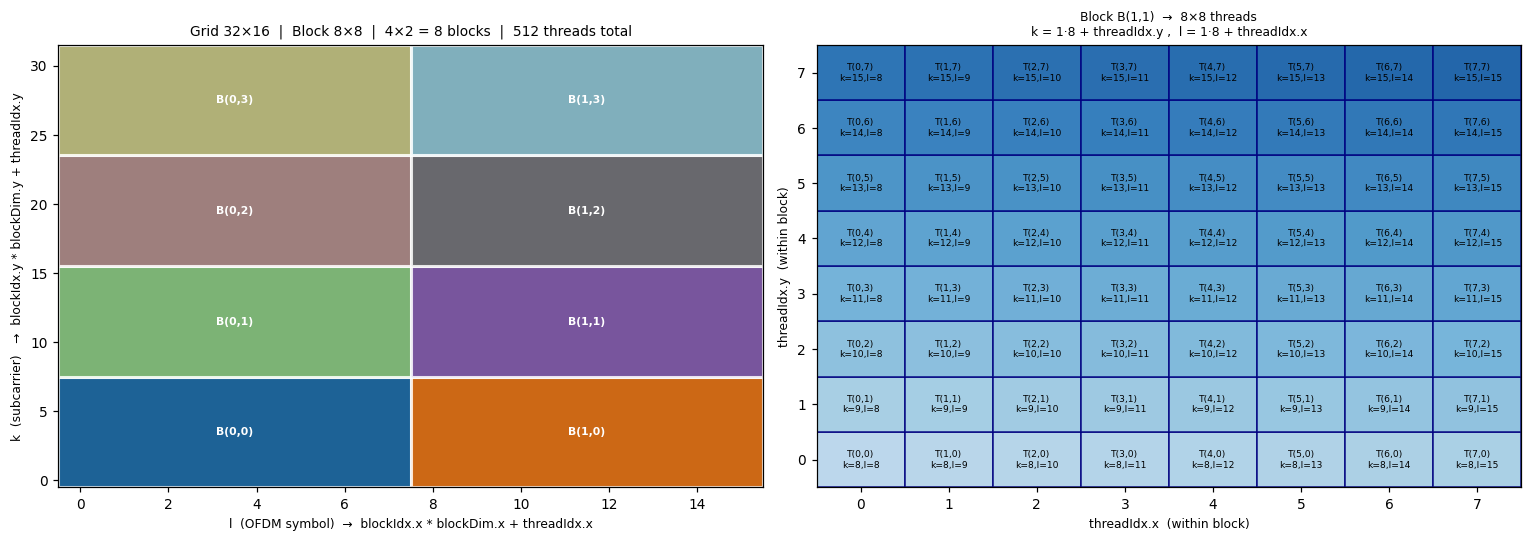

  Threads launched : 512  (4x2 blocks x 64 threads/block)
  Grid cells       : 512
  Idle threads     : 0  <- boundary guard handles these


In [ ]:
# ── CELL 3: Grid Tiling Visualisation Function ────────────────────────────────

def draw_grid_tiling(N_sc, N_sym, block_sz, highlight=(0, 0),
                     ax_left=None, ax_right=None):
    '''
    Left panel : full grid coloured by block (each colour = one CUDA block)
    Right panel: zoom into 'highlight' block, showing thread indices
    '''
    n_bx = math.ceil(N_sym / block_sz)
    n_by = math.ceil(N_sc  / block_sz)
    total = n_bx * n_by * block_sz * block_sz
    idle  = total - N_sc * N_sym

    standalone = (ax_left is None)
    if standalone:
        fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))

    cmap = plt.cm.get_cmap('tab20', n_bx * n_by)

    # ── Left: full grid ────────────────────────────────────────────────────────
    ax_left.set_facecolor('#1a1a2e')
    for by in range(n_by):
        for bx in range(n_bx):
            w = min(block_sz, N_sym - bx * block_sz)
            h = min(block_sz, N_sc  - by * block_sz)
            rect = patches.Rectangle(
                (bx * block_sz - 0.5, by * block_sz - 0.5), w, h,
                lw=2, edgecolor='white', facecolor=cmap(by * n_bx + bx), alpha=0.78)
            ax_left.add_patch(rect)
            cx = bx * block_sz + w / 2 - 0.5
            cy = by * block_sz + h / 2 - 0.5
            ax_left.text(cx, cy, f'B({bx},{by})', ha='center', va='center',
                         fontsize=7, fontweight='bold', color='white')

    ax_left.set_xlim(-0.5, N_sym - 0.5)
    ax_left.set_ylim(-0.5, N_sc  - 0.5)
    ax_left.set_xlabel('l  (OFDM symbol)  \u2192  blockIdx.x * blockDim.x + threadIdx.x', fontsize=8)
    ax_left.set_ylabel('k  (subcarrier)   \u2192  blockIdx.y * blockDim.y + threadIdx.y', fontsize=8)
    ax_left.set_title(
        f'Grid {N_sc}\u00d7{N_sym}  |  Block {block_sz}\u00d7{block_sz}  |  '
        f'{n_by}\u00d7{n_bx} = {n_bx*n_by} blocks  |  {total} threads total',
        fontsize=9)

    # ── Right: zoom into one block ─────────────────────────────────────────────
    bx0, by0 = highlight
    ax_right.set_facecolor('#f0f4ff')
    blues = plt.cm.Blues(np.linspace(0.3, 0.85, block_sz * block_sz))
    t = 0
    for ty in range(block_sz):
        for tx in range(block_sz):
            k_g = by0 * block_sz + ty
            l_g = bx0 * block_sz + tx
            valid = (k_g < N_sc and l_g < N_sym)
            fc = blues[t] if valid else '#dddddd'
            rect2 = patches.Rectangle(
                (tx - 0.5, ty - 0.5), 1, 1,
                lw=1, edgecolor='navy', facecolor=fc, alpha=0.9)
            ax_right.add_patch(rect2)
            lbl = f'T({tx},{ty})\nk={k_g},l={l_g}' if block_sz <= 8 else f'{tx},{ty}'
            ax_right.text(tx, ty, lbl, ha='center', va='center',
                          fontsize=6, color='black' if valid else '#aaaaaa')
            t += 1

    ax_right.set_xlim(-0.5, block_sz - 0.5)
    ax_right.set_ylim(-0.5, block_sz - 0.5)
    ax_right.set_xlabel('threadIdx.x  (within block)', fontsize=8)
    ax_right.set_ylabel('threadIdx.y  (within block)', fontsize=8)
    ax_right.set_title(
        f'Block B({bx0},{by0})  \u2192  {block_sz}\u00d7{block_sz} threads\n'
        f'k = {by0}\u00b7{block_sz} + threadIdx.y ,  l = {bx0}\u00b7{block_sz} + threadIdx.x',
        fontsize=8)

    if standalone:
        plt.tight_layout()
        plt.show()
        print(f'  Threads launched : {total}  ({n_by}x{n_bx} blocks x {block_sz**2} threads/block)')
        print(f'  Grid cells       : {N_sc * N_sym}')
        print(f'  Idle threads     : {idle}  <- boundary guard handles these')

# Static demo
print('Static block-thread diagram (BLOCK_SIZE = 8):')
draw_grid_tiling(N_SC, N_SYM, block_sz=8, highlight=(1, 1))

In [ ]:
# ── CELL 4: Interactive Block Size Explorer ───────────────────────────────────
# Drag the slider — watch the grid retile and thread counts update live.

@widgets.interact(
    block_size=widgets.IntSlider(
        value=8, min=2, max=16, step=2,
        description='Block size (NxN):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='430px')))
def update_grid(block_size):
    draw_grid_tiling(N_SC, N_SYM, block_size, highlight=(0, 0))
    n_bx = math.ceil(N_SYM / block_size)
    n_by = math.ceil(N_SC  / block_size)
    total = n_bx * n_by * block_size ** 2
    print(f'  Block {block_size}x{block_size} = {block_size**2} threads/block  |  '
          f'Grid = {n_by}x{n_bx} = {n_bx*n_by} blocks  |  '
          f'Total threads = {total}  |  Idle = {total - N_SC*N_SYM}')

interactive(children=(IntSlider(value=8, description='Block size (NxN):', layout=Layout(width='430px'), max=16…

---
## Section 2 — Kernel 1: Pilot Mask Initialisation

---

### Code Annotation Guide — how to read the kernel cells

Every code cell from here onwards is annotated with one of the markers below.  
**Only the `◆ CUDA` lines matter for GPU programming** — the rest is scaffolding.

<table style="border-collapse:collapse; font-family:monospace; font-size:13px;">
<tr>
  <td style="background:#c8f7c5; padding:6px 12px; border:1px solid #aaa;"><b>◆ CUDA DEVICE</b></td>
  <td style="padding:6px 12px; border:1px solid #aaa;">The CUDA C kernel string — runs on the GPU. This is what you write as a developer.</td>
</tr>
<tr>
  <td style="background:#c8f7c5; padding:6px 12px; border:1px solid #aaa;"><b>◆ CUDA ALLOC</b></td>
  <td style="padding:6px 12px; border:1px solid #aaa;"><code>cuda.mem_alloc()</code> — allocate a buffer in GPU DRAM (not CPU RAM).</td>
</tr>
<tr>
  <td style="background:#c8f7c5; padding:6px 12px; border:1px solid #aaa;"><b>◆ CUDA H2D</b></td>
  <td style="padding:6px 12px; border:1px solid #aaa;"><code>cuda.memcpy_htod()</code> — copy data from CPU RAM → GPU DRAM (Host to Device).</td>
</tr>
<tr>
  <td style="background:#c8f7c5; padding:6px 12px; border:1px solid #aaa;"><b>◆ CUDA LAUNCH</b></td>
  <td style="padding:6px 12px; border:1px solid #aaa;">Kernel launch call — PyCUDA equivalent of <code>kernel&lt;&lt;&lt;grid, block&gt;&gt;&gt;(args)</code> in C++.</td>
</tr>
<tr>
  <td style="background:#c8f7c5; padding:6px 12px; border:1px solid #aaa;"><b>◆ CUDA SYNC</b></td>
  <td style="padding:6px 12px; border:1px solid #aaa;"><code>synchronize()</code> — CPU blocks until all GPU threads have finished.</td>
</tr>
<tr>
  <td style="background:#c8f7c5; padding:6px 12px; border:1px solid #aaa;"><b>◆ CUDA D2H</b></td>
  <td style="padding:6px 12px; border:1px solid #aaa;"><code>cuda.memcpy_dtoh()</code> — copy result from GPU DRAM → CPU RAM (Device to Host).</td>
</tr>
<tr>
  <td style="background:#fff3cd; padding:6px 12px; border:1px solid #aaa;"><b>── [BENCH] ──</b></td>
  <td style="padding:6px 12px; border:1px solid #aaa;">Timing / benchmarking block — CUDA Events for GPU-side measurement. Not core logic.</td>
</tr>
<tr>
  <td style="background:#f8d7da; padding:6px 12px; border:1px solid #aaa;"><b>── [VIZ] ──</b></td>
  <td style="padding:6px 12px; border:1px solid #aaa;">Matplotlib / NumPy visualisation — zero CUDA. Skip this when learning GPU programming.</td>
</tr>
</table>

---

### The telecom context
Before transmitting, the sender places **known pilot symbols** at fixed positions in the 2D resource grid. The receiver uses these to estimate the channel. We mark these positions with a binary mask.

### The CUDA lesson
Every thread writes to **exactly one cell** — independently, with no communication. This is the simplest possible 2D parallel task.

```
CPU:                              GPU:
for k in range(N_sc):             k = blockIdx.y * blockDim.y + threadIdx.y
  for l in range(N_sym):          l = blockIdx.x * blockDim.x + threadIdx.x
    mask[k,l] = formula(k,l)      mask[k*N_sym+l] = formula(k,l)   // same!
```

The **formula is identical** — only the loop structure changes.

CPU pilot mask  : 221.4 us   (512 sequential iterations)
Pilot positions : 16


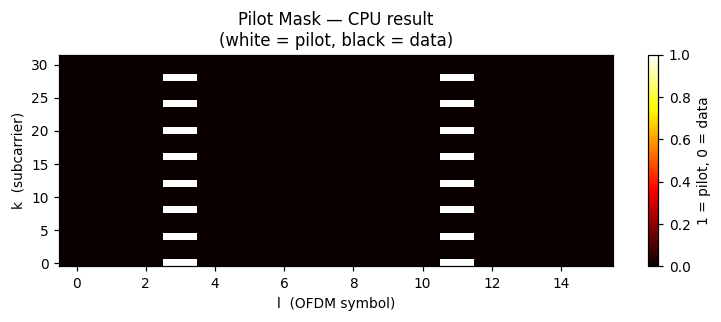

In [ ]:
# ── CELL 5: Kernel 1 — Pilot Mask, CPU version ────────────────────────────────

def pilot_mask_cpu(N_sc, N_sym):
    # CPU executes these loops SEQUENTIALLY — one cell at a time on a single core.
    mask = np.zeros((N_sc, N_sym), dtype=np.float32)
    for k in range(N_sc):        # outer loop — subcarrier (row)     → becomes threadIdx.y / blockIdx.y on GPU
        for l in range(N_sym):   # inner loop — OFDM symbol (column) → becomes threadIdx.x / blockIdx.x on GPU
            # Pilot rule: every 4th subcarrier, at OFDM symbol positions 3 and 11
            if k % 4 == 0 and (l == 3 or l == 11):
                mask[k, l] = 1.0
    return mask

t0 = time.perf_counter()
mask_ref = pilot_mask_cpu(N_SC, N_SYM)
cpu_us_k1 = (time.perf_counter() - t0) * 1e6

print(f'CPU pilot mask  : {cpu_us_k1:.1f} us   ({N_SC*N_SYM} sequential iterations)')
print(f'Pilot positions : {int(mask_ref.sum())}')

plt.figure(figsize=(7, 3))
plt.imshow(mask_ref, aspect='auto', cmap='hot', origin='lower')
plt.xlabel('l  (OFDM symbol)'); plt.ylabel('k  (subcarrier)')
plt.title('Pilot Mask — CPU result\n(white = pilot, black = data)')
plt.colorbar(label='1 = pilot, 0 = data')
plt.tight_layout(); plt.show()

In [ ]:
# ── CELL 6: Kernel 1 — Pilot Mask, GPU version ───────────────────────────────

# ╔══════════════════════════════════════════════════════════════╗
# ║  ◆ CUDA DEVICE CODE — runs on GPU, written in CUDA C        ║
# ║  __global__ = called by CPU host, executed by many threads  ║
# ║  Each thread gets a UNIQUE (blockIdx, threadIdx) — no loops ║
# ╚══════════════════════════════════════════════════════════════╝
KERNEL_1 = '''
__global__ void fill_pilot_mask(float* mask, int N_sc, int N_sym)
{
    /* 2D global thread index — replaces the two CPU for-loops entirely */
    int k = blockIdx.y * blockDim.y + threadIdx.y;   /* subcarrier (row)    */
    int l = blockIdx.x * blockDim.x + threadIdx.x;   /* OFDM symbol (col)   */

    /* Boundary guard: grid is ceiled, so edge threads may be out of range */
    if (k < N_sc && l < N_sym)
        /* Row-major flat index: same as mask[k][l] in a 2D C array */
        mask[k * N_sym + l] =
            ((k % 4 == 0) && (l == 3 || l == 11)) ? 1.0f : 0.0f;
}
'''

mod1 = SourceModule(KERNEL_1)                              # ◆ CUDA: JIT-compile via nvcc
fill_pilot_mask_gpu = mod1.get_function('fill_pilot_mask') # ◆ CUDA: get callable handle

mask_gpu_buf = cuda.mem_alloc(N_SC * N_SYM * 4)           # ◆ CUDA ALLOC: float32 buffer in GPU DRAM

# ◆ CUDA LAUNCH CONFIG — equivalent to dim3 in C++ CUDA
# C++:    dim3 threadsPerBlock(8,8);  dim3 numBlocks(GX,GY);
#         fill_pilot_mask<<<numBlocks, threadsPerBlock>>>(mask, N_SC, N_SYM);
# PyCUDA: fill_pilot_mask_gpu(..., block=(8,8,1), grid=(GX,GY,1))
BLOCK_K1 = 8                          # ◆ threads per block each dim  (8×8 = 64/block)
GX_K1 = math.ceil(N_SYM / BLOCK_K1)  # ◆ blocks along x — OFDM symbol axis
GY_K1 = math.ceil(N_SC  / BLOCK_K1)  # ◆ blocks along y — subcarrier axis

# warm-up (first launch carries driver-init overhead — not representative)
fill_pilot_mask_gpu(mask_gpu_buf, np.int32(N_SC), np.int32(N_SYM),
                    block=(BLOCK_K1, BLOCK_K1, 1), grid=(GX_K1, GY_K1, 1))  # ◆ CUDA LAUNCH
cuda.Context.synchronize()                                 # ◆ CUDA SYNC: CPU waits for GPU

# ══════════════════════════ [ BENCH ] ═════════════════════════════════════════
# WHAT IS BEING TIMED:
#   ✔  GPU kernel execution  (fill_pilot_mask — 512 threads in parallel)
#   ✗  mem_alloc             (done once above, not per-call overhead)
#   ✗  memcpy_dtoh           (done once below, outside this loop)
#   NOTE: fill_pilot_mask has NO input — it only WRITES the mask using
#         thread indices. So there is no H2D transfer needed at all.
#
# WHY CUDA EVENTS, NOT time.perf_counter:
#   CUDA launches are asynchronous — the CPU returns immediately after
#   submitting a kernel. time.perf_counter() on the CPU would measure
#   near-zero (just the submission time, not the actual GPU work).
#   CUDA Events are timestamps placed INTO the GPU command stream —
#   they measure actual GPU execution time, not CPU wall time.
#
# FAIR COMPARISON: both CPU and GPU use the same N_REPS repetitions.
N_REPS = 200

# --- CPU: re-time over N_REPS for a fair average (same rep count as GPU) ---
import time as _time
_t0 = _time.perf_counter()
for _ in range(N_REPS):
    pilot_mask_cpu(N_SC, N_SYM)
cpu_us_k1_avg = (_time.perf_counter() - _t0) / N_REPS * 1e6   # µs per call

# --- GPU: CUDA Events time ONLY the kernel execution ---
ev_s = cuda.Event(); ev_e = cuda.Event()                   # ◆ CUDA EVENTS: GPU-side timers
ev_s.record()                                              # ◆ timestamp placed in GPU stream
for _ in range(N_REPS):
    fill_pilot_mask_gpu(mask_gpu_buf, np.int32(N_SC), np.int32(N_SYM),
                        block=(BLOCK_K1, BLOCK_K1, 1), grid=(GX_K1, GY_K1, 1))  # ◆ LAUNCH
ev_e.record(); ev_e.synchronize()                          # ◆ CUDA SYNC: wait, then read timer
gpu_us_k1 = ev_s.time_till(ev_e) * 1e3 / N_REPS           # convert ms → µs, divide by reps
# ══════════════════════════ [ /BENCH ] ════════════════════════════════════════

# ◆ CUDA D2H: copy result from GPU DRAM back to CPU RAM — happens once, outside benchmark
mask_gpu_result = np.empty((N_SC, N_SYM), dtype=np.float32)
cuda.memcpy_dtoh(mask_gpu_result, mask_gpu_buf)

print(f'Both measured over {N_REPS} repetitions — per-call average:')
print(f'  CPU sequential loops  : {cpu_us_k1_avg:.1f} µs')
print(f'  GPU kernel only       : {gpu_us_k1:.2f} µs  '
      f'(block={BLOCK_K1}×{BLOCK_K1}, grid={GX_K1}×{GY_K1})')
print(f'  NOTE: GPU time = pure kernel compute only (no memcpy overhead)')
print()



Both measured over 200 repetitions — per-call average:
  CPU sequential loops  : 27.6 µs
  GPU kernel only       : 9.27 µs  (block=8×8, grid=2×4)
  NOTE: GPU time = pure kernel compute only (no memcpy overhead)



---
## ★ Key Takeaways — Cell 5 (CPU) vs Cell 6 (GPU)

> These two cells show the **same task** done two ways.  
> Comparing them gives you the single most important insight of the lab.

---

### 1. Replace the two outer loops with two thread-index lines — that is GPU programming

| | CPU (Cell 5) | GPU (Cell 6) |
|--|-------------|-------------|
| Row loop | `for k in range(N_SC):` | `k = blockIdx.y * blockDim.y + threadIdx.y` |
| Column loop | `for l in range(N_SYM):` | `l = blockIdx.x * blockDim.x + threadIdx.x` |
| Computation | same `if` rule | **identical** `if` rule |
| Execution | 512 iterations, **one at a time** | 512 threads, **all at once** |

> The body of the loop — the actual computation — is identical on CPU and GPU.  
> Only the loop structure changes. This pattern repeats in every kernel in the lab.

---

### 2. The boundary guard is the programmer's responsibility

The CPU loops run from exactly `0` to `N_SC-1` and stop — no overflow possible.  
The GPU grid is rounded up with `ceil()`, so some edge threads are launched beyond the data.  
The `if` statement is how each thread checks whether it has valid work:

```c
if (k < N_sc && l < N_sym)       // ← thread asks itself: "do I have a valid cell?"
    mask[k * N_sym + l] = ...;   // only valid threads write — edge threads exit cleanly
```

Without this guard: **memory corruption**. With it: edge threads simply exit harmlessly.

---

### 3. GPU setup cost is real — the GPU wins only at scale

Cell 6 introduces the full CUDA workflow that every kernel must go through:

```
SourceModule(...)       ← JIT-compile CUDA C code
get_function(...)       ← get a callable handle
cuda.mem_alloc(...)     ← allocate buffer in GPU DRAM
memcpy_htod(...)        ← copy input from CPU RAM → GPU DRAM  (PCIe bus)
kernel<<<G, B>>>(...)   ← launch 512 threads
Context.synchronize()   ← CPU waits for GPU to finish
memcpy_dtoh(...)        ← copy result from GPU DRAM → CPU RAM  (PCIe bus)
```

For 512 cells this overhead makes the GPU **slower** than the CPU.  
The GPU breaks even and then dominates as `N_SC` grows toward real 5G sizes (1200 × 14 = 16,800 cells).  
This is measured precisely in the **Scaling Experiment** cell that follows Kernel 2.

---

### The one-line summary

> **CPU programmer writes loops. GPU programmer replaces those loops with thread-index arithmetic and adds a boundary guard. Everything else is the same.**

---
## Section 3 — Kernel 2: Element-wise Channel Application

### Y[k, l] = H[k, l] × X[k, l]

When a transmitted signal **X** passes through channel **H**, each resource element is multiplied independently.
This is **embarrassingly parallel**: no thread needs any result from another thread.

| | CPU | GPU |
|---|---|---|
| Outer loop 1 | `for k in range(N_sc):` | `k = blockIdx.y * blockDim.y + threadIdx.y` |
| Outer loop 2 | `  for l in range(N_sym):` | `l = blockIdx.x * blockDim.x + threadIdx.x` |
| Computation | `    Y[k,l] = H[k,l]*X[k,l]` | `Y[idx] = H[idx] * X[idx];` |

**The computation is identical.** Only the loop structure changes.

max |CPU - GPU| = 0.00e+00
  → 0.00e+00 = bit-identical: single float32 multiply is fully deterministic


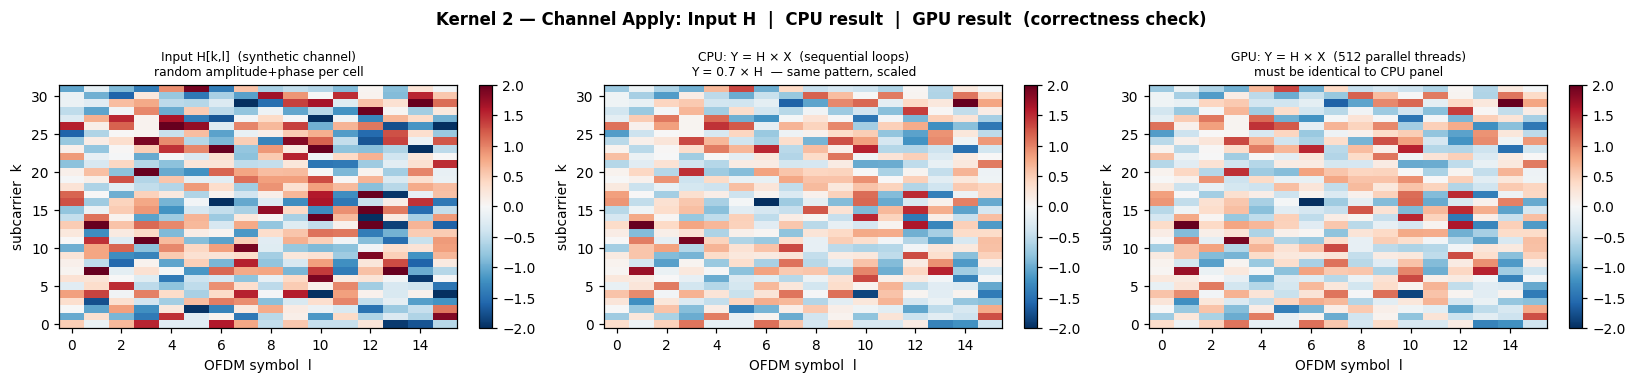

In [ ]:
# ── CELL 7: Kernel 2 — Channel Apply, CPU + GPU ───────────────────────────────
#
# WHAT THIS KERNEL DOES:
#   Simulates the wireless channel acting on every transmitted symbol.
#   Equation: Y[k, l] = H[k, l] × X[k, l]
#     H[k, l] = channel coefficient at subcarrier k, OFDM symbol l
#               (complex gain — amplitude scaling + phase rotation by the air)
#     X[k, l] = transmitted data symbol at (k, l)
#     Y[k, l] = received signal after passing through H — this is what the
#               receiver "hears"
#   This is the TRANSMITTER/CHANNEL SIDE of the lab — H is synthetic (known).
#   The CNN (Kernel 3) is the RECEIVER SIDE — it estimates H from Y + pilots.
#
# WHY IT IS "EMBARRASSINGLY PARALLEL":
#   Each cell (k, l) depends on ONLY its own H and X — nothing else.
#   → All 512 multiplications are completely independent of each other.
#   → Every thread can run at the exact same time — zero waiting, zero sync.
#   This is the ideal GPU workload.

# ── PART A: CPU reference — sequential, one cell at a time ─────────────────────
# The CPU visits every (k, l) cell one by one using two nested loops.
# This is correct but slow: 512 iterations on a single core.
# KEY OBSERVATION: the two outer loops are the ONLY difference vs the GPU version.
#                  The computation inside (H*X) is identical on both.
def apply_channel_cpu(H, X):
    Y = np.empty_like(H)
    for k in range(H.shape[0]):      # outer loop: subcarrier (row)   → GPU: blockIdx.y * blockDim.y + threadIdx.y
        for l in range(H.shape[1]):  # inner loop: OFDM symbol (col)  → GPU: blockIdx.x * blockDim.x + threadIdx.x
            Y[k, l] = H[k, l] * X[k, l]   # same multiply — runs on GPU too, unchanged
    return Y

# ── PART B: GPU kernel — all 512 threads run simultaneously ────────────────────
# ╔══════════════════════════════════════════════════════════════╗
# ║  ◆ CUDA DEVICE CODE  — embarrassingly parallel kernel       ║
# ║  Every thread works on its OWN cell — zero inter-thread dep ║
# ╚══════════════════════════════════════════════════════════════╝
# The two nested CPU loops are COMPLETELY REPLACED by the two index lines below.
# The multiplication Y[idx] = H[idx] * X[idx] is byte-for-byte the same logic.
KERNEL_2 = '''
__global__ void apply_channel(float* Y, const float* H, const float* X,
                               int N_sc, int N_sym)
{
    /* ── Step 1: each thread computes its unique (k, l) position ── */
    /* These two lines replace the entire "for k / for l" CPU loop.  */
    int k   = blockIdx.y * blockDim.y + threadIdx.y;  /* subcarrier  (row)   */
    int l   = blockIdx.x * blockDim.x + threadIdx.x;  /* OFDM symbol (col)   */

    /* ── Step 2: convert 2D position to flat array index ── */
    /* GPU memory is 1D. Row-major: row k starts at k * N_sym. */
    int idx = k * N_sym + l;

    /* ── Step 3: boundary guard — required because grid is ceiled ── */
    /* ceil(32/16)=2, ceil(16/16)=1 → grid exactly covers 32×16, no overflow here. */
    /* Always include this guard — it costs nothing and prevents memory corruption. */
    if (k < N_sc && l < N_sym)
        /* ── Step 4: the actual work — ONE multiply, fully independent ── */
        /* Thread reads only H[idx] and X[idx] — both belong to THIS thread alone. */
        /* No other thread touches these cells → safe to run all 512 in parallel.  */
        Y[idx] = H[idx] * X[idx];
}
'''
mod2 = SourceModule(KERNEL_2)                              # ◆ CUDA: JIT-compile CUDA C via nvcc
apply_channel_gpu = mod2.get_function('apply_channel')     # ◆ CUDA: get Python-callable handle

# ── PART C: Prepare test data ──────────────────────────────────────────────────
# H_small: synthetic channel — random values simulate amplitude+phase distortion
# X_small: all 0.7 — a flat transmitted signal (constant for easy visual checking)
np.random.seed(42)
H_small = np.random.randn(N_SC, N_SYM).astype(np.float32)   # shape (32, 16), in CPU RAM
X_small = (np.ones_like(H_small) * 0.7).astype(np.float32)  # shape (32, 16), in CPU RAM

# Run CPU version first — this becomes the reference answer for correctness check
Y_cpu_k2 = apply_channel_cpu(H_small, X_small)   # lives in CPU RAM

# ── PART D: GPU memory management — RULE: GPU can only read GPU memory ─────────
# The GPU has its own separate DRAM. It CANNOT directly access CPU RAM.
# Every array the kernel reads or writes must be:
#   1) allocated in GPU DRAM   (cuda.mem_alloc)
#   2) filled with data        (cuda.memcpy_htod — for input arrays only)
#
#   Array  | kernel reads? | kernel writes? | alloc? | H2D copy?
#   -------|---------------|----------------|--------|----------
#   H_g    |     YES       |      no        |  YES   |   YES
#   X_g    |     YES       |      no        |  YES   |   YES
#   Y_g    |      no       |     YES        |  YES   |    no  ← output only, kernel fills it
#
H_g = cuda.mem_alloc(H_small.nbytes)   # ◆ CUDA ALLOC: reserve 2048 bytes in GPU DRAM for H
X_g = cuda.mem_alloc(X_small.nbytes)   # ◆ CUDA ALLOC: reserve 2048 bytes in GPU DRAM for X
Y_g = cuda.mem_alloc(H_small.nbytes)   # ◆ CUDA ALLOC: reserve 2048 bytes in GPU DRAM for Y (output)

cuda.memcpy_htod(H_g, H_small)         # ◆ CUDA H2D: H crosses PCIe bus — CPU RAM → GPU DRAM
cuda.memcpy_htod(X_g, X_small)         # ◆ CUDA H2D: X crosses PCIe bus — CPU RAM → GPU DRAM
# Y_g is NOT copied — it is an empty output buffer; the kernel will write into it

# ── PART E: Launch configuration ───────────────────────────────────────────────
# Block: 16×16 = 256 threads per block  (sweet spot for 2D kernels on T4)
# Grid:  ceil(16/16)=1 along x (time), ceil(32/16)=2 along y (freq)
#        → 1×2 = 2 blocks total × 256 threads = 512 threads launched
#        → exactly one thread per (k, l) cell, no overflow
BLK_K2 = 16                            # ◆ CUDA LAUNCH CONFIG: 16×16 = 256 threads/block
apply_channel_gpu(Y_g, H_g, X_g, np.int32(N_SC), np.int32(N_SYM),
                  block=(BLK_K2, BLK_K2, 1),
                  grid=(math.ceil(N_SYM/BLK_K2), math.ceil(N_SC/BLK_K2), 1))  # ◆ CUDA LAUNCH
# After this line returns: the GPU has computed all 512 Y[k,l] values in GPU DRAM.
# The CPU cannot read them yet — they are still on the GPU side.

# ── PART F: Copy result back to CPU ────────────────────────────────────────────
Y_gpu_k2 = np.empty_like(H_small)
cuda.memcpy_dtoh(Y_gpu_k2, Y_g)        # ◆ CUDA D2H: Y crosses PCIe bus — GPU DRAM → CPU RAM
# Now Y_gpu_k2 is a normal numpy array in CPU RAM — Python can use it freely.

# ── PART G: Correctness check ──────────────────────────────────────────────────
# Single float32 multiply is DETERMINISTIC — CPU and GPU produce bit-identical results.
# max difference = 0.00e+00 means every one of the 512 cells is exactly equal.
# (For Kernel 3 with 9-term accumulation, expect ~1e-7 due to float rounding order.)
print(f'max |CPU - GPU| = {np.max(np.abs(Y_cpu_k2 - Y_gpu_k2)):.2e}')
print(f'  → 0.00e+00 = bit-identical: single float32 multiply is fully deterministic')

# ══════════════════════════════ [ VIZ ] ═══════════════════════════════════════
# PURPOSE: show what the channel does visually.
#   Panel 1 (Input H):  the random channel — each cell has a different gain/phase
#   Panel 2 (CPU Y):    received signal from CPU  — H pattern scaled by X=0.7
#   Panel 3 (GPU Y):    received signal from GPU  — must look identical to Panel 2
# If Panel 2 and Panel 3 look the same → GPU kernel is correct.
# Since X=0.7 (constant), Y = 0.7 × H — the Y panels are just H scaled down.
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
panels = [
    (H_small,  'Input H[k,l]  (synthetic channel)\nrandom amplitude+phase per cell'),
    (Y_cpu_k2, 'CPU: Y = H × X  (sequential loops)\nY = 0.7 × H  — same pattern, scaled'),
    (Y_gpu_k2, 'GPU: Y = H × X  (512 parallel threads)\nmust be identical to CPU panel'),
]
for ax, (data, title) in zip(axes, panels):
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', origin='lower', vmin=-2, vmax=2)
    ax.set_xlabel('OFDM symbol  l'); ax.set_ylabel('subcarrier  k')
    ax.set_title(title, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Kernel 2 — Channel Apply: Input H  |  CPU result  |  GPU result  (correctness check)',
             fontweight='bold')
plt.tight_layout(); plt.show()

Scaling experiment: CPU nested loop vs GPU 2D kernel
GPU time = H2D + kernel + D2H  (full realistic pipeline per call)

  N_SC=   32  (   448 cells):  CPU=0.3837 ms   GPU=0.0570 ms  (H+X = 3584 bytes across PCIe)
  N_SC=   64  (   896 cells):  CPU=0.7971 ms   GPU=0.0544 ms  (H+X = 7168 bytes across PCIe)
  N_SC=  128  (  1792 cells):  CPU=1.5431 ms   GPU=0.0617 ms  (H+X = 14336 bytes across PCIe)
  N_SC=  256  (  3584 cells):  CPU=2.5839 ms   GPU=0.0568 ms  (H+X = 28672 bytes across PCIe)
  N_SC=  512  (  7168 cells):  CPU=3.4463 ms   GPU=0.0668 ms  (H+X = 57344 bytes across PCIe)
  N_SC= 1024  ( 14336 cells):  CPU=7.4876 ms   GPU=0.0895 ms  (H+X = 114688 bytes across PCIe)
  N_SC= 1200  ( 16800 cells):  CPU=8.1364 ms   GPU=0.0912 ms  (H+X = 134400 bytes across PCIe)
  N_SC= 2048  ( 28672 cells):  CPU=27.4420 ms   GPU=0.1731 ms  (H+X = 229376 bytes across PCIe)


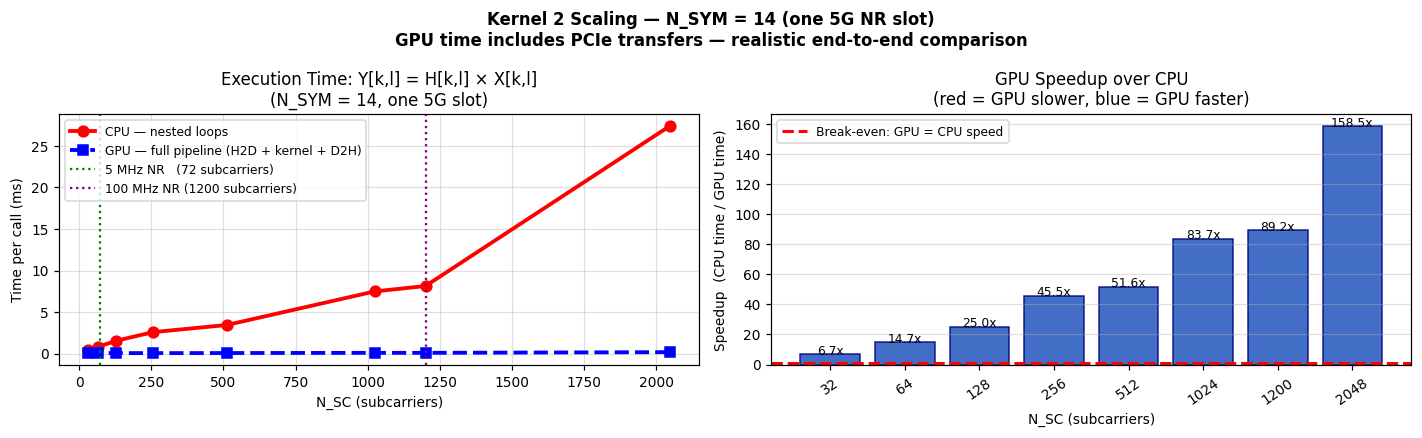


  At 1200 subcarriers (100 MHz 5G NR): GPU is 89.2x faster
  This is the real operating point — GPU parallelism pays off at this scale.


In [ ]:
# ── CELL 8: Kernel 2 — Scaling Experiment ────────────────────────────────────
#
# QUESTION THIS CELL ANSWERS:
#   "At what grid size does the GPU start winning over the CPU?"
#
# WHY THIS QUESTION MATTERS:
#   Cell 7 showed the GPU is CORRECT. But is it FASTER?
#   For a tiny 32×16 lab grid, the GPU overhead (memory alloc, PCIe transfers)
#   may outweigh the benefit of parallel execution.
#   This cell sweeps N_SC from 32 → 2048 to find the crossover point
#   and shows what happens at real 5G NR sizes (72 and 1200 subcarriers).
#
# WHAT IS TIMED ON THE GPU SIDE:
#   The GPU time INCLUDES the full realistic pipeline per call:
#     1. H2D: copy H from CPU RAM → GPU DRAM  (PCIe bus)
#     2. H2D: copy X from CPU RAM → GPU DRAM  (PCIe bus)
#     3. kernel: apply_channel runs on GPU     (parallel compute)
#     4. D2H: copy Y from GPU DRAM → CPU RAM  (PCIe bus)
#   This is the RIGHT way to benchmark — in a real 5G receiver,
#   all four steps must happen every slot. Measuring kernel-only
#   would give an unrealistically optimistic GPU number.
#
# WHAT IS TIMED ON THE CPU SIDE:
#   The CPU time measures only the nested-loop function apply_channel_cpu().
#   Both CPU and GPU use N_REPS_K2 = 30 repetitions, averaged.

print('Scaling experiment: CPU nested loop vs GPU 2D kernel')
print('GPU time = H2D + kernel + D2H  (full realistic pipeline per call)')
print()

# Grid sizes to test: lab size → real 5G NR bandwidths
# 5G NR 5 MHz  →  72 subcarriers
# 5G NR 100 MHz → 1200 subcarriers
# 2048 is beyond 5G — shows trend continuation
sizes_k2   = [32, 64, 128, 256, 512, 1024, 1200, 2048]
N_SYM_TEST = 14     # one 5G NR slot = 14 OFDM symbols (fixed across all sizes)
N_REPS_K2  = 30     # repeat 30 times and average — reduces measurement noise
cpu_ms_k2  = []
gpu_ms_k2  = []

for N in sizes_k2:
    # Generate fresh random H and flat X for this grid size
    H_t = np.random.randn(N, N_SYM_TEST).astype(np.float32)   # shape (N, 14), in CPU RAM
    X_t = np.ones((N, N_SYM_TEST), dtype=np.float32)           # shape (N, 14), in CPU RAM

    # ── CPU TIMING ──────────────────────────────────────────────────────────────
    # time.perf_counter() measures CPU wall time.
    # Run N_REPS_K2 times to get a stable average — single-run CPU times
    # can vary ±30% due to OS scheduling and cache effects.
    t0 = time.perf_counter()
    for _ in range(N_REPS_K2):
        apply_channel_cpu(H_t, X_t)
    cpu_ms_k2.append((time.perf_counter() - t0) / N_REPS_K2 * 1000)   # ms per call

    # ── GPU SETUP (outside timing loop — done once per grid size) ───────────────
    # mem_alloc is a one-time cost per buffer size, not per kernel call.
    # In a real system these buffers are allocated at startup and reused every slot.
    Hg_t = cuda.mem_alloc(H_t.nbytes)   # ◆ CUDA ALLOC: GPU buffer for H  (N×14 float32)
    Xg_t = cuda.mem_alloc(X_t.nbytes)   # ◆ CUDA ALLOC: GPU buffer for X
    Yg_t = cuda.mem_alloc(H_t.nbytes)   # ◆ CUDA ALLOC: GPU buffer for Y  (output)

    # Block and grid sizes scale with N_SC — ceil ensures full coverage
    BLK  = 16                            # 16×16 = 256 threads/block (fixed sweet spot)
    GX_t = math.ceil(N_SYM_TEST / BLK)  # blocks along time axis  (always 1 for 14 syms)
    GY_t = math.ceil(N / BLK)           # blocks along freq axis  (grows with N_SC)

    # ── WARM-UP RUN (not timed) ──────────────────────────────────────────────────
    # The very first CUDA launch on a context carries driver-init overhead
    # (JIT cache miss, kernel load, etc.) — not representative of steady-state.
    # One warm-up run burns this overhead before the timed loop starts.
    cuda.memcpy_htod(Hg_t, H_t); cuda.memcpy_htod(Xg_t, X_t)
    apply_channel_gpu(Yg_t, Hg_t, Xg_t, np.int32(N), np.int32(N_SYM_TEST),
                      block=(BLK, BLK, 1), grid=(GX_t, GY_t, 1))
    cuda.Context.synchronize()   # ◆ CUDA SYNC: wait for warm-up to finish before starting timer

    # ── GPU TIMING — CUDA Events measure GPU-side elapsed time ──────────────────
    # CUDA Event timestamps are placed INTO the GPU command stream.
    # ev_s.record() marks the start; ev_e.record() marks the end.
    # time_till() reads the hardware timer on the GPU — unaffected by CPU scheduling.
    # This captures H2D + kernel + D2H together as one end-to-end measurement.
    ev_s = cuda.Event(); ev_e = cuda.Event()
    ev_s.record()                          # ◆ CUDA: start GPU timer
    for _ in range(N_REPS_K2):
        # Step 1 & 2: copy inputs from CPU RAM to GPU DRAM across PCIe bus
        cuda.memcpy_htod(Hg_t, H_t)        # ◆ CUDA H2D: H  (N×14 floats across PCIe)
        cuda.memcpy_htod(Xg_t, X_t)        # ◆ CUDA H2D: X  (N×14 floats across PCIe)

        # Step 3: launch kernel — all N×14 threads run in parallel on GPU
        apply_channel_gpu(Yg_t, Hg_t, Xg_t, np.int32(N), np.int32(N_SYM_TEST),
                          block=(BLK, BLK, 1), grid=(GX_t, GY_t, 1))   # ◆ CUDA LAUNCH

        # Step 4: copy output from GPU DRAM back to CPU RAM
        _tmp = np.empty_like(H_t)
        cuda.memcpy_dtoh(_tmp, Yg_t)       # ◆ CUDA D2H: Y  (N×14 floats across PCIe)
    ev_e.record(); ev_e.synchronize()      # ◆ CUDA SYNC: wait for all reps to finish
    gpu_ms_k2.append(ev_s.time_till(ev_e) / N_REPS_K2)   # ms per call (averaged)

    print(f'  N_SC={N:5d}  ({N*N_SYM_TEST:6d} cells):  '
          f'CPU={cpu_ms_k2[-1]:.4f} ms   GPU={gpu_ms_k2[-1]:.4f} ms  '
          f'(H+X = {H_t.nbytes + X_t.nbytes} bytes across PCIe)')

# Speedup = CPU time / GPU time.
# speedup > 1 → GPU is faster.  speedup < 1 → GPU is slower (PCIe overhead dominates).
speedup_k2 = [c / g for c, g in zip(cpu_ms_k2, gpu_ms_k2)]

# ══════════════════════════════ [ VIZ ] ═══════════════════════════════════════
# Left plot  — execution time vs N_SC: shows WHERE the two lines cross.
#   Red line  (CPU): grows linearly with N_SC — more cells = proportionally more time
#   Blue line (GPU): nearly flat for small N (PCIe dominates), then levels off
#   Green/purple vertical lines: real 5G NR bandwidth reference points
#
# Right plot — speedup bar chart: bars ABOVE red dashed line (1.0) = GPU wins.
#   Red bars   = GPU is slower than CPU (small grids — PCIe cost > compute saving)
#   Blue bars  = GPU is faster than CPU (large grids — parallel compute dominates)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(sizes_k2, cpu_ms_k2, 'o-r',  lw=2.5, ms=7, label='CPU — nested loops')
axes[0].plot(sizes_k2, gpu_ms_k2, 's--b', lw=2.5, ms=7, label='GPU — full pipeline (H2D + kernel + D2H)')
axes[0].axvline(72,   color='green',  ls=':', lw=1.5, label='5 MHz NR   (72 subcarriers)')
axes[0].axvline(1200, color='purple', ls=':', lw=1.5, label='100 MHz NR (1200 subcarriers)')
axes[0].set_xlabel('N_SC (subcarriers)'); axes[0].set_ylabel('Time per call (ms)')
axes[0].set_title('Execution Time: Y[k,l] = H[k,l] × X[k,l]\n(N_SYM = 14, one 5G slot)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.4)

bar_colors = ['#cc3333' if s < 1 else '#2255bb' for s in speedup_k2]
axes[1].bar(range(len(sizes_k2)), speedup_k2, color=bar_colors, edgecolor='navy', alpha=0.85)
axes[1].axhline(1.0, color='red', ls='--', lw=2, label='Break-even: GPU = CPU speed')
axes[1].set_xticks(range(len(sizes_k2)))
axes[1].set_xticklabels([str(s) for s in sizes_k2], rotation=35)
axes[1].set_xlabel('N_SC (subcarriers)'); axes[1].set_ylabel('Speedup  (CPU time / GPU time)')
axes[1].set_title('GPU Speedup over CPU\n(red = GPU slower, blue = GPU faster)')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.4)
for i, s in enumerate(speedup_k2):
    axes[1].text(i, s + 0.05, f'{s:.1f}x', ha='center', fontsize=8)

plt.suptitle('Kernel 2 Scaling — N_SYM = 14 (one 5G NR slot)\n'
             'GPU time includes PCIe transfers — realistic end-to-end comparison',
             fontweight='bold')
plt.tight_layout(); plt.show()

if 1200 in sizes_k2:
    idx = sizes_k2.index(1200)
    print(f'\n  At 1200 subcarriers (100 MHz 5G NR): GPU is {speedup_k2[idx]:.1f}x faster')
    print(f'  This is the real operating point — GPU parallelism pays off at this scale.')

---
## Section 4 — Kernel 3: 2D Convolution (One CNN Layer)

### The channel estimation CNN
The MathWorks 5G Toolbox example and Nokia's real pipeline use a CNN:
- **Input:** sparse pilot observation grid (zeros at non-pilot positions)
- **Each Conv2D layer** slides a small filter over the 2D grid
- **Output:** estimated channel H across all resource elements

Each output cell `output[k, l]` is computed by reading a 3×3 neighbourhood:
```
output[k,l] = sum over (dk,dl) in [-1,0,1]^2 of:  input[k+dk, l+dl] * weight[dk,dl]
```

### The GPU insight — outer loops become thread indices

```
CPU:                                    GPU:
──────────────────────────────────────  ──────────────────────────────────────────────
for k in range(N_sc):                   k = blockIdx.y * blockDim.y + threadIdx.y
  for l in range(N_sym):                l = blockIdx.x * blockDim.x + threadIdx.x
    for dk in [-1,0,1]:                 for (dk = -1; dk <= 1; dk++) {  // SAME
      for dl in [-1,0,1]:                 for (dl = -1; dl <= 1; dl++) { // SAME
        val += input[k+dk,l+dl]*w           val += input[...] * w[...];  // SAME
```

The **inner dk, dl loops are identical** in CPU and GPU. Only the outer 2 loops change.

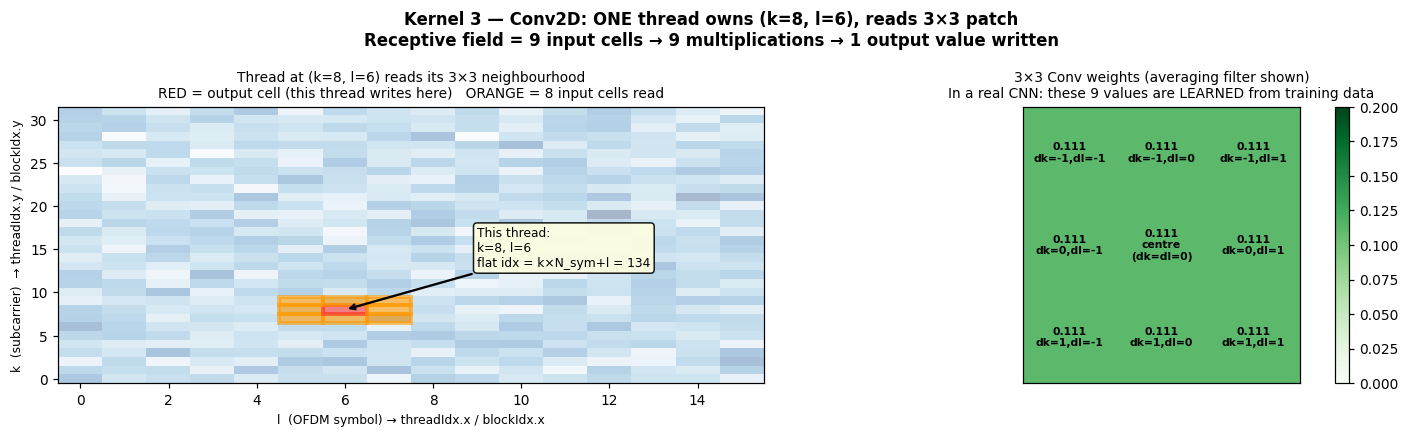

In [ ]:
# ── CELL 9: Conv Neighbourhood Visual ────────────────────────────────────────
#
# WHAT THIS CELL DOES:
#   Draws a visual diagram of ONE GPU thread's job in Kernel 3 (Conv2D).
#   It answers the question: "What exactly does a single thread do in Conv2D?"
#
# THE KEY IDEA — Kernel 3 is different from Kernels 1 and 2:
#   Kernel 1: each thread WRITES to its own cell only       (no reads from neighbours)
#   Kernel 2: each thread READS its own H and X, writes Y   (no reads from neighbours)
#   Kernel 3: each thread READS a 3×3 NEIGHBOURHOOD of cells, writes ONE output cell
#             → the thread "looks around" before it writes
#
# CONV2D OPERATION (what the thread computes):
#   output[k, l] = sum over (dk, dl) in {-1, 0, +1}² of:
#                     input[k+dk, l+dl] × weight[dk, dl]
#   = 9 multiplications + 8 additions per thread
#   Each thread still writes to ONLY ITS OWN output[k, l] — parallel on output cells.
#
# THE TWO PANELS:
#   Left panel:  full 32×16 grid showing thread (k0, l0):
#                  RED   = the output cell this thread OWNS and writes
#                  ORANGE = the 8 surrounding cells this thread READS (neighbours)
#                  Together the red + orange cells form the 3×3 patch = the receptive field
#
#   Right panel: the 3×3 filter (weight array):
#                  Each orange + red position corresponds to one weight value.
#                  Averaging filter (1/9 each) is shown as an example.
#                  In a real CNN, these 9 weights are LEARNED during training.
#
# WHY THIS MATTERS FOR GPU UNDERSTANDING:
#   Each thread reads 9 input cells but writes only 1 output cell.
#   9 threads reading the same cell is fine — reads never conflict.
#   Writing is safe because no two threads share an output cell (each owns one unique (k,l)).
#   → This is still parallel on the output, even though input reads overlap.

def draw_conv_neighbourhood(k0, l0, N_sc=32, N_sym=16):
    # k0, l0 = the (subcarrier, OFDM symbol) of the thread being visualised
    # N_sc, N_sym = total grid dimensions (used for boundary checks)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── LEFT PANEL: full grid with the thread's receptive field highlighted ───────
    ax = axes[0]
    # faint background signal — represents the input data on the resource grid
    bg = np.random.RandomState(7).randn(N_sc, N_sym) * 0.4
    ax.imshow(bg, aspect='auto', cmap='Blues', origin='lower', alpha=0.35)

    # Highlight all 9 cells in the 3×3 neighbourhood
    # dk, dl ∈ {-1, 0, +1} — the 3×3 offsets around the centre (k0, l0)
    for dk in range(-1, 2):
        for dl in range(-1, 2):
            r, c = k0 + dk, l0 + dl
            if 0 <= r < N_sc and 0 <= c < N_sym:   # boundary: skip cells outside the grid
                # RED   = centre cell (dk=0, dl=0) — this is the OUTPUT cell this thread writes
                # ORANGE = the 8 surrounding input cells this thread reads
                col = '#ff3333' if (dk == 0 and dl == 0) else '#ff9900'
                ax.add_patch(patches.Rectangle(
                    (c - 0.5, r - 0.5), 1, 1,
                    lw=2.5, edgecolor=col, facecolor=col, alpha=0.6))

    # Axis labels show the CUDA index mapping: l → threadIdx.x, k → threadIdx.y
    ax.set_xlabel('l  (OFDM symbol) → threadIdx.x / blockIdx.x', fontsize=8)
    ax.set_ylabel('k  (subcarrier)  → threadIdx.y / blockIdx.y', fontsize=8)
    ax.set_title(
        f'Thread at (k={k0}, l={l0}) reads its 3×3 neighbourhood\n'
        f'RED = output cell (this thread writes here)   ORANGE = 8 input cells read',
        fontsize=9)

    # Annotation: show this thread's flat memory index = k0 * N_sym + l0
    ax.annotate(
        f'This thread:\nk={k0}, l={l0}\nflat idx = k×N_sym+l = {k0*N_sym+l0}',
        xy=(l0, k0), xytext=(l0 + 3, k0 + 5),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

    # ── RIGHT PANEL: the 3×3 filter weight array ──────────────────────────────────
    ax2 = axes[1]
    # Averaging filter: all 9 weights = 1/9 = 0.111
    # This is a simple example — in a real channel estimation CNN, the 9 weights
    # are learned during training to optimally interpolate the channel H.
    w = np.ones((3, 3)) / 9.0
    im2 = ax2.imshow(w, cmap='Greens', vmin=0, vmax=0.2)

    # Label each cell with its value and its (dk, dl) offset from the centre
    for i in range(3):
        for j in range(3):
            lbl = 'centre\n(dk=dl=0)' if (i == 1 and j == 1) else f'dk={i-1},dl={j-1}'
            ax2.text(j, i, f'{w[i,j]:.3f}\n{lbl}',
                     ha='center', va='center', fontsize=7, fontweight='bold')
    ax2.set_title('3×3 Conv weights (averaging filter shown)\n'
                  'In a real CNN: these 9 values are LEARNED from training data',
                  fontsize=9)
    ax2.set_xticks([]); ax2.set_yticks([])
    plt.colorbar(im2, ax=ax2, fraction=0.046)

    plt.suptitle(
        f'Kernel 3 — Conv2D: ONE thread owns (k={k0}, l={l0}), reads 3×3 patch\n'
        f'Receptive field = 9 input cells → 9 multiplications → 1 output value written',
        fontweight='bold')
    plt.tight_layout(); plt.show()

# Visualise thread at subcarrier k=8, OFDM symbol l=6 as the example
# Change k0 and l0 to any (k, l) position to see a different thread's view
draw_conv_neighbourhood(8, 6)

CPU conv2d : 15.0357 ms  (4 nested loops)
GPU conv2d : 0.2746 ms  (2D kernel)
Max error  : 1.79e-07  <- identical


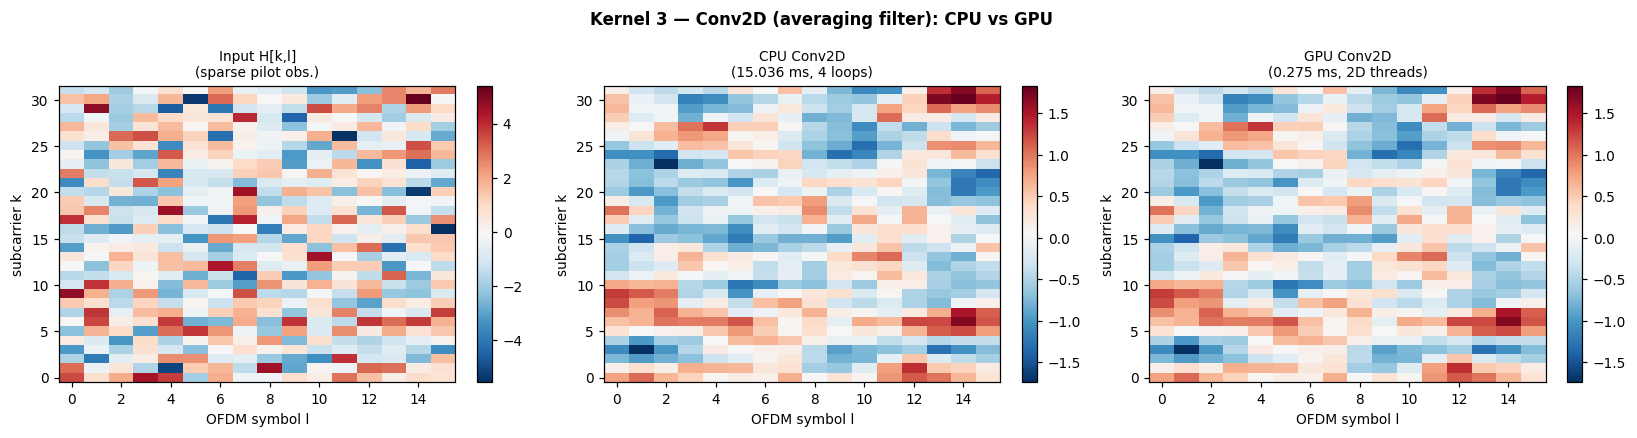

In [ ]:
# ── CELL 11: Kernel 3 — Conv2D, CPU + GPU ────────────────────────────────────

# CPU: 4 nested loops running sequentially on one core
def conv2d_cpu(signal, kernel3x3):
    N_sc, N_sym = signal.shape
    out = np.zeros_like(signal)
    for k in range(N_sc):            # outer loop 1 — subcarrier  → GPU: blockIdx.y*blockDim.y+threadIdx.y
        for l in range(N_sym):       # outer loop 2 — OFDM symbol → GPU: blockIdx.x*blockDim.x+threadIdx.x
            val = 0.0
            for dk in range(-1, 2):  # inner loop 1 — 3×3 row offset  (kept unchanged in GPU kernel)
                for dl in range(-1, 2):  # inner loop 2 — 3×3 col offset  (kept unchanged in GPU kernel)
                    r, c = k + dk, l + dl
                    if 0 <= r < N_sc and 0 <= c < N_sym:
                        val += signal[r, c] * kernel3x3[dk + 1, dl + 1]
            out[k, l] = val
    return out

# ╔══════════════════════════════════════════════════════════════╗
# ║  ◆ CUDA DEVICE CODE  — 2D kernel replaces 2 outer loops     ║
# ║  Outer loops  → thread indices  (parallelised by GPU)       ║
# ║  Inner loops  → stay inside kernel  (run by every thread)   ║
# ╚══════════════════════════════════════════════════════════════╝
KERNEL_3 = '''
__global__ void conv2d_pass(const float* input, const float* w,
                             float* output, int N_sc, int N_sym)
{
    /* Outer loops replaced by thread indices — one thread per output cell */
    int k = blockIdx.y * blockDim.y + threadIdx.y;   /* subcarrier  (row)   */
    int l = blockIdx.x * blockDim.x + threadIdx.x;   /* OFDM symbol (col)   */

    if (k < N_sc && l < N_sym) {
        float val = 0.0f;
        /* Inner 3×3 loops are UNCHANGED — each thread runs them independently */
        for (int dk = -1; dk <= 1; dk++) {
            for (int dl = -1; dl <= 1; dl++) {
                int r = k + dk,  c = l + dl;
                /* Zero-pad at boundaries instead of out-of-bounds access */
                float px = (r >= 0 && r < N_sc && c >= 0 && c < N_sym)
                            ? input[r * N_sym + c] : 0.0f;
                /* Weight index: (dk+1)*3+(dl+1) maps offsets [-1,1] → [0,8] */
                val += px * w[(dk + 1) * 3 + (dl + 1)];
            }
        }
        output[k * N_sym + l] = val;   /* write result to this thread's output cell */
    }
}
'''
mod3 = SourceModule(KERNEL_3)
conv2d_gpu_fn = mod3.get_function('conv2d_pass')

# Averaging filter (box blur)
smooth_w = np.ones((3, 3), dtype=np.float32) / 9.0
np.random.seed(0)
H_conv_in = (np.random.randn(N_SC, N_SYM) * 2.0).astype(np.float32)

# CPU run
t0 = time.perf_counter()
cpu_conv_out = conv2d_cpu(H_conv_in, smooth_w)
cpu_ms_k3 = (time.perf_counter() - t0) * 1000

# GPU run
# H2D: copy filter weights and input signal from CPU RAM to GPU DRAM
w_g3   = cuda.mem_alloc(smooth_w.nbytes)                   # ◆ CUDA ALLOC: filter weights buffer
in_g3  = cuda.mem_alloc(H_conv_in.nbytes)                  # ◆ CUDA ALLOC: input signal buffer
out_g3 = cuda.mem_alloc(H_conv_in.nbytes)                  # ◆ CUDA ALLOC: output buffer
cuda.memcpy_htod(w_g3,  smooth_w.flatten())                # ◆ CUDA H2D: weights → GPU DRAM
cuda.memcpy_htod(in_g3, H_conv_in)                         # ◆ CUDA H2D: input  → GPU DRAM

# ◆ CUDA LAUNCH CONFIG: 16×16 = 256 threads/block; grid covers N_SC × N_SYM
BLK_K3 = 16
GX_K3 = math.ceil(N_SYM / BLK_K3)   # ◆ blocks along x — OFDM symbol axis
GY_K3 = math.ceil(N_SC  / BLK_K3)   # ◆ blocks along y — subcarrier axis

# ══════════════════════════ [ BENCH ] ═════════════════════════════════════════
ev_s = cuda.Event(); ev_e = cuda.Event()                   # ◆ CUDA EVENTS: create timers
ev_s.record()                                              # ◆ CUDA: mark stream start
conv2d_gpu_fn(in_g3, w_g3, out_g3, np.int32(N_SC), np.int32(N_SYM),
              block=(BLK_K3, BLK_K3, 1), grid=(GX_K3, GY_K3, 1))  # ◆ CUDA LAUNCH
ev_e.record(); ev_e.synchronize()                          # ◆ CUDA SYNC: wait for GPU
gpu_ms_k3 = ev_s.time_till(ev_e)                           # kernel-only time (no transfer)
# ══════════════════════════ [ /BENCH ] ════════════════════════════════════════

gpu_conv_out = np.empty_like(H_conv_in)
cuda.memcpy_dtoh(gpu_conv_out, out_g3)                     # ◆ CUDA D2H: GPU DRAM → CPU RAM

print(f'CPU conv2d : {cpu_ms_k3:.4f} ms  (4 nested loops)')
print(f'GPU conv2d : {gpu_ms_k3:.4f} ms  (2D kernel)')
print(f'Max error  : {np.max(np.abs(cpu_conv_out - gpu_conv_out)):.2e}  <- identical')

# ══════════════════════════════ [ VIZ ] ═══════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes,
        [H_conv_in, cpu_conv_out, gpu_conv_out],
        ['Input H[k,l]\n(sparse pilot obs.)',
         f'CPU Conv2D\n({cpu_ms_k3:.3f} ms, 4 loops)',
         f'GPU Conv2D\n({gpu_ms_k3:.3f} ms, 2D threads)']):
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', origin='lower')
    ax.set_xlabel('OFDM symbol l'); ax.set_ylabel('subcarrier k')
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Kernel 3 — Conv2D (averaging filter): CPU vs GPU', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── CELL 12: Interactive Filter Widget ───────────────────────────────────────
# Change the filter weights — the GPU kernel re-runs with each selection.
# In the real CNN, these weights would be LEARNED from channel data.

FILTERS = {
    'Averaging (smooth)':   np.ones((3, 3), dtype=np.float32) / 9.0,
    'Sharpen':              np.array([[ 0,-1, 0],[-1, 5,-1],[ 0,-1, 0]], dtype=np.float32),
    'Edge detect (horiz)':  np.array([[-1,-1,-1],[ 0, 0, 0],[ 1, 1, 1]], dtype=np.float32),
    'Edge detect (vert)':   np.array([[-1, 0, 1],[-1, 0, 1],[-1, 0, 1]], dtype=np.float32),
    'Identity (no change)': np.array([[ 0, 0, 0],[ 0, 1, 0],[ 0, 0, 0]], dtype=np.float32),
}

out_g3b = cuda.mem_alloc(H_conv_in.nbytes)

@widgets.interact(
    filter_name=widgets.Dropdown(
        options=list(FILTERS.keys()),
        value='Averaging (smooth)',
        description='Filter:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='380px')))
def apply_filter_widget(filter_name):
    w = FILTERS[filter_name].flatten()
    wg_tmp = cuda.mem_alloc(w.nbytes)
    cuda.memcpy_htod(wg_tmp, w)
    conv2d_gpu_fn(in_g3, wg_tmp, out_g3b, np.int32(N_SC), np.int32(N_SYM),
                  block=(BLK_K3, BLK_K3, 1), grid=(GX_K3, GY_K3, 1))
    cuda.Context.synchronize()
    result = np.empty_like(H_conv_in)
    cuda.memcpy_dtoh(result, out_g3b)

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].imshow(H_conv_in, aspect='auto', cmap='RdBu_r', origin='lower')
    axes[0].set_title('Input H[k,l]'); axes[0].set_xlabel('l'); axes[0].set_ylabel('k')

    im = axes[1].imshow(result, aspect='auto', cmap='RdBu_r', origin='lower')
    axes[1].set_title(f'GPU output with "{filter_name}" filter')
    axes[1].set_xlabel('l')
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    w2d = FILTERS[filter_name]
    im2 = axes[2].imshow(w2d, cmap='RdBu_r', vmin=-2, vmax=5)
    for i in range(3):
        for j in range(3):
            axes[2].text(j, i, f'{w2d[i,j]:.2f}',
                         ha='center', va='center', fontsize=11, fontweight='bold')
    axes[2].set_title('3x3 Filter weights\n(CNN: learned from training data)')
    axes[2].set_xticks([]); axes[2].set_yticks([])
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    plt.suptitle(
        f'GPU Conv2D with "{filter_name}" filter\n'
        'channel estimation CNN uses learned weights — same CUDA kernel code',
        fontsize=10)
    plt.tight_layout(); plt.show()
    print(f'  Filter: {filter_name}')
    print(f'  Weights: {w2d.tolist()}')

interactive(children=(Dropdown(description='Filter:', layout=Layout(width='380px'), options=('Averaging (smoot…

Conv2D scaling: CPU (4 nested loops) vs GPU (2D kernel)

  N=   32: CPU=2.258 ms   GPU=0.0110 ms   speedup=206x
  N=   64: CPU=4.522 ms   GPU=0.0100 ms   speedup=452x
  N=  128: CPU=9.599 ms   GPU=0.0101 ms   speedup=947x
  N=  256: CPU=19.127 ms   GPU=0.0165 ms   speedup=1160x
  N=  512: CPU=36.995 ms   GPU=0.0200 ms   speedup=1850x
  N= 1024: CPU=72.349 ms   GPU=0.0124 ms   speedup=5840x
  N= 1200: CPU=83.943 ms   GPU=0.0110 ms   speedup=7662x
  N= 2048: CPU=160.170 ms   GPU=0.0167 ms   speedup=9572x


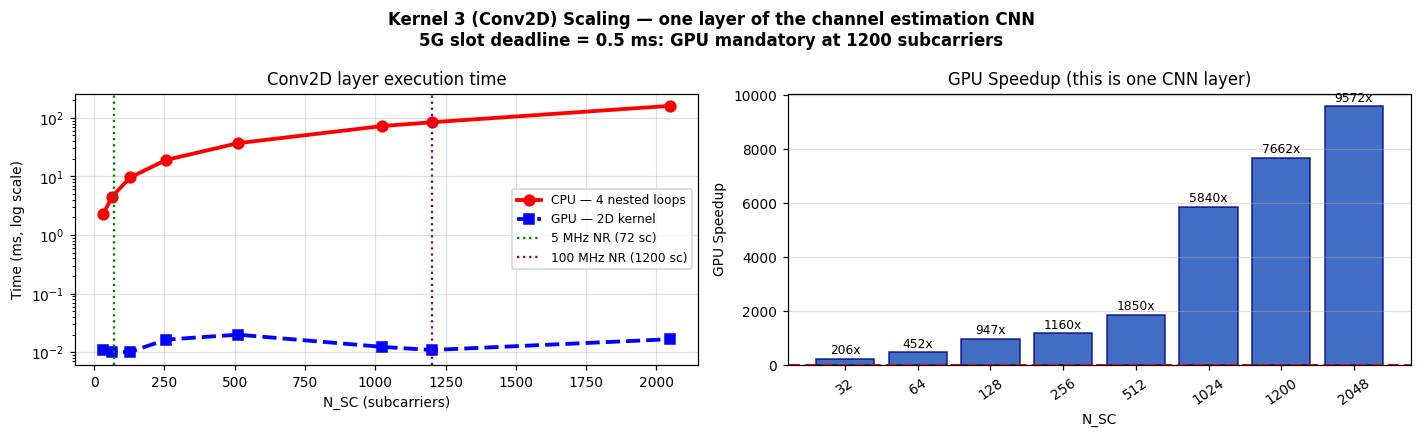


  At 1200 subcarriers (100 MHz 5G NR):
    CPU: 83.94 ms   GPU: 0.011 ms
    Speedup: 7662x
    5G slot = 0.5 ms -> GPU makes real-time inference feasible


In [ ]:
# ── CELL 13: Conv2D Scaling ───────────────────────────────────────────────────
# How does conv2d performance scale as the grid grows toward real 5G sizes?

print('Conv2D scaling: CPU (4 nested loops) vs GPU (2D kernel)')
print()

sizes_k3   = [32, 64, 128, 256, 512, 1024, 1200, 2048]
N_SYM_C    = 14
N_REPS_K3  = 20
cpu_ms_k3s = []
gpu_ms_k3s = []

for N in sizes_k3:
    sig = np.random.randn(N, N_SYM_C).astype(np.float32)

    # CPU
    t0 = time.perf_counter()
    for _ in range(N_REPS_K3):
        conv2d_cpu(sig, smooth_w)
    cpu_ms_k3s.append((time.perf_counter() - t0) / N_REPS_K3 * 1000)

    # GPU
    sg = cuda.mem_alloc(sig.nbytes); cuda.memcpy_htod(sg, sig)
    og = cuda.mem_alloc(sig.nbytes)
    wg = cuda.mem_alloc(smooth_w.nbytes); cuda.memcpy_htod(wg, smooth_w.flatten())
    BLK = 16
    GX_c = math.ceil(N_SYM_C / BLK); GY_c = math.ceil(N / BLK)
    # warmup
    conv2d_gpu_fn(sg, wg, og, np.int32(N), np.int32(N_SYM_C),
                  block=(BLK, BLK, 1), grid=(GX_c, GY_c, 1))
    cuda.Context.synchronize()
    ev_s = cuda.Event(); ev_e = cuda.Event()
    ev_s.record()
    for _ in range(N_REPS_K3):
        conv2d_gpu_fn(sg, wg, og, np.int32(N), np.int32(N_SYM_C),
                      block=(BLK, BLK, 1), grid=(GX_c, GY_c, 1))
    ev_e.record(); ev_e.synchronize()
    gpu_ms_k3s.append(ev_s.time_till(ev_e) / N_REPS_K3)
    print(f'  N={N:5d}: CPU={cpu_ms_k3s[-1]:.3f} ms   GPU={gpu_ms_k3s[-1]:.4f} ms   '
          f'speedup={cpu_ms_k3s[-1]/gpu_ms_k3s[-1]:.0f}x')

speedup_k3 = [c / g for c, g in zip(cpu_ms_k3s, gpu_ms_k3s)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(sizes_k3, cpu_ms_k3s, 'o-r', lw=2.5, ms=7, label='CPU — 4 nested loops')
axes[0].semilogy(sizes_k3, gpu_ms_k3s, 's--b', lw=2.5, ms=7, label='GPU — 2D kernel')
axes[0].axvline(72,   color='green',  ls=':', lw=1.5, label='5 MHz NR (72 sc)')
axes[0].axvline(1200, color='purple', ls=':', lw=1.5, label='100 MHz NR (1200 sc)')
axes[0].set_xlabel('N_SC (subcarriers)'); axes[0].set_ylabel('Time (ms, log scale)')
axes[0].set_title('Conv2D layer execution time')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.4)

axes[1].bar(range(len(sizes_k3)), speedup_k3,
            color=['#cc3333' if s < 1 else '#2255bb' for s in speedup_k3],
            edgecolor='navy', alpha=0.85)
axes[1].axhline(1.0, color='red', ls='--', lw=2)
axes[1].set_xticks(range(len(sizes_k3)))
axes[1].set_xticklabels([str(s) for s in sizes_k3], rotation=35)
axes[1].set_xlabel('N_SC'); axes[1].set_ylabel('GPU Speedup')
axes[1].set_title('GPU Speedup (this is one CNN layer)')
for i, s in enumerate(speedup_k3):
    axes[1].text(i, s + max(speedup_k3)*0.02, f'{s:.0f}x', ha='center', fontsize=8)
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle(
    'Kernel 3 (Conv2D) Scaling — one layer of the channel estimation CNN\n'
    '5G slot deadline = 0.5 ms: GPU mandatory at 1200 subcarriers',
    fontweight='bold')
plt.tight_layout(); plt.show()

if 1200 in sizes_k3:
    idx = sizes_k3.index(1200)
    print(f'\n  At 1200 subcarriers (100 MHz 5G NR):')
    print(f'    CPU: {cpu_ms_k3s[idx]:.2f} ms   GPU: {gpu_ms_k3s[idx]:.3f} ms')
    print(f'    Speedup: {speedup_k3[idx]:.0f}x')
    print(f'    5G slot = 0.5 ms -> GPU makes real-time inference feasible')

---
## Section 5 — Block Size Experiment

We now run Kernel 3 (conv2d) with different 2D block sizes and measure:
1. **Kernel execution time** — does block size affect speed?
2. **Output correctness** — does block size affect the result?

---

### What to expect — and WHY

---

#### Observation 1 — Correctness NEVER changes with block size

The output `conv2d(input, weights)` is mathematically independent of how threads are grouped.

```
Thread at (k=5, l=3) always computes:
  output[5,3] = sum over 3×3 neighbourhood of  input[k+dk, l+dl] × weight[dk, dl]

Whether it is in block (0,0) with 8×8 grouping,
OR in block (0,0) with 16×16 grouping —
the thread's (k, l) values are the same, so the computation is identical.
```

> **Rule:** Block size changes WHERE a thread lives in the grid, never WHAT it computes.  
> `max error vs CPU = 0.00e+00` for every block size — expected and correct.

---

#### Observation 2 — Speed DOES change with block size

Block size affects three hardware-level factors:

**Factor 1 — Warp count per block**

A warp = 32 consecutive threads that execute as one SIMD unit.  
The number of warps per block = `(block_x × block_y) / 32`

| Block size | Threads/block | Warps/block | Notes |
|-----------|--------------|-------------|-------|
| 2×2       | 4            | < 1 warp    | Wastes most of a warp — very inefficient |
| 4×4       | 16           | 0.5 warps   | Still under one full warp |
| 8×8       | 64           | 2 warps     | Acceptable for small grids |
| **16×16** | **256**      | **8 warps** | **★ Sweet spot — 8 full warps per block** |
| 32×32     | 1024         | 32 warps    | Maximum allowed — may limit active blocks |

> Incomplete warps waste GPU vector units. A 4×4 block (16 threads) fills only half a warp —  
> 16 SIMD lanes sit idle every instruction cycle.

**Factor 2 — SM Occupancy**

Each SM can hold a limited number of blocks and threads simultaneously.  
Too few threads per block → SM is underutilised (not enough parallel work to hide memory latency).  
Too many threads per block → fewer blocks fit per SM → SM may be underutilised differently.

```
T4 GPU limits per SM:
  Max threads/SM  = 1024
  Max blocks/SM   = 16
  Max warps/SM    = 32

With 16×16 blocks (256 threads):   1024 / 256 = 4 blocks per SM  →  high occupancy
With 4×4  blocks (16  threads):    1024 / 16  = 64 blocks per SM →  but capped at 16 → wasted
With 32×32 blocks (1024 threads):  1024 / 1024 = 1 block per SM  →  low occupancy
```

**Factor 3 — Hardware limit: 1024 threads per block**

`block_x × block_y ≤ 1024` on ALL modern NVIDIA GPUs (T4, V100, A100, H100).  
If you exceed this: the kernel launch silently fails or raises an error.  
32×32 = 1024 is the maximum. 33×33 = 1089 would fail.

---

#### The 5-column table: what the experiment measures for each block size

| Block | Threads/block | Warps | Grid (for 32×16) | Expected behaviour |
|-------|--------------|-------|------------------|--------------------|
| 2×2   | 4            | <1    | 16×8 = 128 blocks | Slowest — warp waste, many tiny blocks |
| 4×4   | 16           | 0.5   | 8×4  = 32 blocks  | Still slow |
| 8×8   | 64           | 2     | 4×2  = 8 blocks   | Getting better |
| **16×16** | **256** | **8** | **1×2 = 2 blocks** | **Fastest on T4 for this grid size** |

> **Note:** for this lab's tiny 32×16 grid, performance differences are small.  
> At real 5G scale (1200×14), the choice of block size matters much more.

---

#### The two outputs to look for when you run the slider

```
Block NxN:  time = X.XXXX ms  |  max error vs CPU = 0.00e+00  <- correctness unchanged
            ↑ this changes      ↑ this is ALWAYS 0 — confirms block size never affects result
```

> **Drag the slider → watch the timing bar change → confirm error stays at 0.00e+00 every time.**

> Drag the slider below to explore each block size. The tiling diagram and timing bar update together.e each block size. The tiling diagram and timing bar update together.

In [ ]:
# ── CELL 14: Interactive Block Size Experiment ────────────────────────────────
#
# WHAT THIS CELL PROVES (interactively):
#   1. Correctness  — max error vs CPU stays 0.00e+00 for EVERY block size
#                     Block grouping never changes what a thread computes.
#   2. Speed        — kernel time changes with block size
#                     Small blocks → warp waste → slower
#                     16×16        → 8 full warps/block → fastest on T4
#                     32×32        → hits hardware limit (1024 threads/block max)
#
# HOW IT WORKS:
#   - Same CUDA kernel (conv2d_gpu_fn) is launched with different block= dimensions
#   - The kernel code is UNCHANGED — only block=(bx,by,1) and grid=(gx,gy,1) change
#   - timing_store caches results so each block size is only measured once
#   - Slider re-runs run_block_exp() with the selected block_size

# ── One shared input and output buffer — reused across all block size experiments ──
# All block sizes operate on the same data so timing differences reflect only the
# block configuration, not data variation.
sig_exp   = np.random.randn(N_SC, N_SYM).astype(np.float32)          # input signal (CPU RAM)
sig_g_exp = cuda.mem_alloc(sig_exp.nbytes)                             # ◆ CUDA ALLOC: input on GPU
cuda.memcpy_htod(sig_g_exp, sig_exp)                                   # ◆ CUDA H2D: copy input
out_g_exp = cuda.mem_alloc(sig_exp.nbytes)                             # ◆ CUDA ALLOC: output on GPU
w_g_exp   = cuda.mem_alloc(smooth_w.nbytes)                            # ◆ CUDA ALLOC: weights on GPU
cuda.memcpy_htod(w_g_exp, smooth_w.flatten())                          # ◆ CUDA H2D: copy weights

timing_store = {}   # cache: {block_size → ms per kernel call}

# CPU reference — computed ONCE, reused for every block size correctness check
# If the GPU result matches this for ALL block sizes → block grouping never affects output
ref_exp = conv2d_cpu(sig_exp, smooth_w)

def run_block_exp(block_size):
    # ── Measure this block size (once, then cache) ────────────────────────────
    if block_size not in timing_store:
        bx = by = block_size                        # square block: bx × by threads
        gx = math.ceil(N_SYM / bx)                 # blocks along time axis  (x)
        gy = math.ceil(N_SC  / by)                 # blocks along freq axis  (y)
        # Total threads launched = bx×by × gx×gy — always ≥ N_SC × N_SYM (ceil)
        # Boundary guard inside the kernel handles any excess threads safely.

        # Warm-up: first launch has JIT overhead — exclude from timing
        conv2d_gpu_fn(sig_g_exp, w_g_exp, out_g_exp,
                      np.int32(N_SC), np.int32(N_SYM),
                      block=(bx, by, 1), grid=(gx, gy, 1))
        cuda.Context.synchronize()   # ◆ CUDA SYNC: wait for warm-up before starting timer

        # Time 500 repetitions — kernel-only (no H2D/D2H inside loop)
        # This isolates the pure compute cost of different block configurations.
        N_R = 500
        ev_s = cuda.Event(); ev_e = cuda.Event()
        ev_s.record()                              # ◆ CUDA EVENT: start GPU timer
        for _ in range(N_R):
            conv2d_gpu_fn(sig_g_exp, w_g_exp, out_g_exp,
                          np.int32(N_SC), np.int32(N_SYM),
                          block=(bx, by, 1), grid=(gx, gy, 1))  # ◆ CUDA LAUNCH
        ev_e.record(); ev_e.synchronize()          # ◆ CUDA SYNC: wait, then stop timer
        timing_store[block_size] = ev_s.time_till(ev_e) / N_R   # ms per call (averaged)

    ms     = timing_store[block_size]
    tested = sorted(timing_store.keys())
    times  = [timing_store[s] for s in tested]

    # ── Visualisation: 3 panels ──────────────────────────────────────────────
    # Panel 1 (left):  tiling diagram — how the grid is divided into blocks
    #                  Larger blocks = fewer, bigger coloured rectangles
    # Panel 2 (mid):   thread ownership map — which thread owns which cell
    # Panel 3 (right): timing bar chart — red = currently selected block size
    #                  Watch this bar change as you drag the slider
    fig = plt.figure(figsize=(17, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[2, 2, 1.5], wspace=0.35)
    ax_l = fig.add_subplot(gs[0])
    ax_m = fig.add_subplot(gs[1])
    ax_r = fig.add_subplot(gs[2])

    draw_grid_tiling(N_SC, N_SYM, block_size, highlight=(0, 0),
                     ax_left=ax_l, ax_right=ax_m)

    # Red bar = currently selected; blue = previously tested sizes
    bar_colors = ['#cc2222' if s == block_size else '#3377bb' for s in tested]
    ax_r.bar([f'{s}×{s}' for s in tested], times, color=bar_colors, edgecolor='navy', alpha=0.85)
    ax_r.set_xlabel('Block size'); ax_r.set_ylabel('Kernel time (ms)')
    ax_r.set_title(f'Conv2D kernel time (pure compute)\n'
                   f'red = current  |  {block_size}×{block_size} = {block_size**2} threads/block'
                   f' = {block_size**2 // 32} warps/block', fontsize=8)
    ax_r.tick_params(axis='x', rotation=35)
    ax_r.grid(axis='y', alpha=0.4)
    for i, t in enumerate(times):
        ax_r.text(i, t + max(times) * 0.03, f'{t:.3f}', ha='center', fontsize=7)

    plt.suptitle(
        f'Block {block_size}×{block_size}  |  {block_size**2} threads/block  |  '
        f'{block_size**2 // 32} warps/block  |  '
        f'{math.ceil(N_SYM/block_size)}×{math.ceil(N_SC/block_size)} blocks in grid  |  '
        f'Kernel: {ms:.3f} ms',
        fontweight='bold', fontsize=10)
    plt.tight_layout(); plt.show()

    # ── Correctness check: compare GPU output against CPU reference ───────────
    # D2H: copy GPU result back to CPU for comparison
    out_check = np.empty_like(sig_exp)
    cuda.memcpy_dtoh(out_check, out_g_exp)     # ◆ CUDA D2H: result to CPU
    err = np.max(np.abs(out_check - ref_exp))  # max absolute difference across all 512 cells
    warps = block_size ** 2 // 32
    print(f'  Block {block_size:2d}×{block_size:2d}  '
          f'({block_size**2:4d} threads/block, {warps} warps/block):  '
          f'kernel = {ms:.4f} ms  |  '
          f'max error vs CPU = {err:.2e}'
          + ('  ← correctness UNCHANGED' if err < 1e-4 else '  ← ERROR: something is wrong!'))

block_slider_exp = widgets.IntSlider(
    value=8, min=2, max=16, step=2,
    description='Block size (NxN):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='450px'))

widgets.interactive(run_block_exp, block_size=block_slider_exp)

interactive(children=(IntSlider(value=8, description='Block size (NxN):', layout=Layout(width='450px'), max=16…

---
## Summary — What We Learnt

### The 2D Indexing Formula (memorise this)

```python
k   = blockIdx.y * blockDim.y + threadIdx.y   # row  — subcarrier
l   = blockIdx.x * blockDim.x + threadIdx.x   # col  — OFDM symbol
idx = k * N_SYM + l                           # flat row-major memory index
if (k < N_sc && l < N_sym): { ... }           # boundary guard — always include
```

### Three Kernels, Three Lessons

| Kernel | Operation | Lesson |
|--------|-----------|--------|
| **1** `fill_pilot_mask` | Write to own cell | Embarrassingly parallel; every thread independent |
| **2** `apply_channel` | `Y[k,l] = H[k,l] * X[k,l]` | GPU wins at real 5G sizes (>~200 subcarriers) |
| **3** `conv2d_pass` | 3×3 neighbourhood | Outer CPU loops = thread indices; inner loops stay identical |

### The Core Pattern

```
CPU code:                        GPU code:
──────────────────────────────   ──────────────────────────────────────
for k in range(N_sc):            k = blockIdx.y * blockDim.y + threadIdx.y
  for l in range(N_sym):         l = blockIdx.x * blockDim.x + threadIdx.x
    [same computation]           [same computation]
```

> **Replace the 2 outer loops with 2 thread index lines. That is GPU programming.**

### Block Size Rules
- Changing block size changes **speed** — never **correctness**
- Hardware limit: **1024 threads/block** (32×32) on T4, V100, A100
- Sweet spot on T4: **16×16 = 256 threads = 8 warps**
- Warp size = 32: block dimensions that are multiples of 32 are most efficient

### The Industry Connection

```
channel estimation CNN (ChannelNet/ReEsNet style)
  ↓
Multiple Conv2D layers  ← each layer = Kernel 3 above, with LEARNED weights
  ↓
Runs every 5G slot = every 0.5 ms on a T4/A100 GPU in the gNB
  ↓
PyTorch nn.Conv2d → cuDNN → tiled 2D CUDA kernel (same structure as Kernel 3)
  ↓
Same pattern applies at any receiver: gNB, UE, or any device
```

---
